# GPU Cloud Frustration Analysis

NVIDIA, while known for supplying the robust hardware which modern AI systems rely on, began as a video game company. One of its primary sources is hosting its own gaming supercomputers which can be accessed and controlled remotely to allow customers to play resource demanding games without actually owning an expensive gaming computer. In this notebook, we investigate whether daily reviews and sentiment around this service can be used to predict overall customer sentiment shifts during major tech product announcements. 

## Load and inspect the full dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/nvidia_gfn_combined.csv",
    parse_dates=["date"]
)

df.head()

,date,nvda_close,nvda_volume,tsm_close,smh_etf_close,qqq_close,nvda_return_pct,nvda_volatility_30d,nvda_sma_50,nvda_sma_200,is_trading_day,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_avg_thumbs_up,gfn_one_star_share,gfn_negative_share,gfn_positive_share
0,2015-01-01,NaN,0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,0.50325,113680000,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,0.50325,0,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-04,0.50325,0,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-05,0.49475,197952000,21.740000,26.760000,101.430000,-1.689023,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

display(df.head())

Shape: (4280, 18)

Columns:
['date', 'nvda_close', 'nvda_volume', 'tsm_close', 'smh_etf_close', 'qqq_close', 'nvda_return_pct', 'nvda_volatility_30d', 'nvda_sma_50', 'nvda_sma_200', 'is_trading_day', 'gfn_reviews_count', 'gfn_avg_rating', 'gfn_sentiment_score', 'gfn_avg_thumbs_up', 'gfn_one_star_share', 'gfn_negative_share', 'gfn_positive_share']

Data types:
date                   datetime64[ns]
nvda_close                    float64
nvda_volume                     int64
tsm_close                     float64
smh_etf_close                 float64
qqq_close                     float64
nvda_return_pct               float64
nvda_volatility_30d           float64
nvda_sma_50                   float64
nvda_sma_200                  float64
is_trading_day                  int64
gfn_reviews_count               int64
gfn_avg_rating                float64
gfn_sentiment_score           float64
gfn_avg_thumbs_up             float64
gfn_one_star_share            float64
gfn_negative_share            

,missing
date,0
nvda_close,1
nvda_volume,0
tsm_close,1
smh_etf_close,1
qqq_close,1
nvda_return_pct,0
nvda_volatility_30d,47
nvda_sma_50,74
nvda_sma_200,288


,date,nvda_close,nvda_volume,tsm_close,smh_etf_close,qqq_close,nvda_return_pct,nvda_volatility_30d,nvda_sma_50,nvda_sma_200,is_trading_day,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_avg_thumbs_up,gfn_one_star_share,gfn_negative_share,gfn_positive_share
0,2015-01-01,NaN,0,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,0.50325,113680000,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,0.50325,0,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-04,0.50325,0,22.280001,27.245001,102.940002,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-05,0.49475,197952000,21.740000,26.760000,101.430000,-1.689023,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
display(
    df[
        [
            "date",
            "nvda_close",
            "nvda_return_pct",
            "gfn_reviews_count",
            "gfn_avg_rating",
            "gfn_sentiment_score",
            "gfn_negative_share"
        ]
    ].head(20)
)

display(df.describe(include="all"))

,date,nvda_close,nvda_return_pct,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_negative_share
0,2015-01-01,NaN,0.000000,0,NaN,NaN,NaN
1,2015-01-02,0.50325,0.000000,0,NaN,NaN,NaN
2,2015-01-03,0.50325,0.000000,0,NaN,NaN,NaN
3,2015-01-04,0.50325,0.000000,0,NaN,NaN,NaN
4,2015-01-05,0.49475,-1.689023,0,NaN,NaN,NaN
5,2015-01-06,0.47975,-3.031831,0,NaN,NaN,NaN
6,2015-01-07,0.47850,-0.260552,0,NaN,NaN,NaN
7,2015-01-08,0.49650,3.761751,0,NaN,NaN,NaN
8,2015-01-09,0.49850,0.402821,0,NaN,NaN,NaN
9,2015-01-10,0.49850,0.000000,0,NaN,NaN,NaN


,date,nvda_close,nvda_volume,tsm_close,smh_etf_close,qqq_close,nvda_return_pct,nvda_volatility_30d,nvda_sma_50,nvda_sma_200,is_trading_day,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_avg_thumbs_up,gfn_one_star_share,gfn_negative_share,gfn_positive_share
count,4280,4279.000000,4.280000e+03,4279.000000,4279.000000,4279.000000,4280.000000,4233.000000,4206.000000,3992.000000,4280.000000,4280.000000,2269.000000,2269.000000,2269.000000,2269.000000,2269.000000,2269.000000
mean,2020-11-09 12:00:00,43.109703,2.942935e+08,103.379023,131.972217,295.947184,0.173474,2.845156,42.028333,38.750514,0.687850,2.805607,2.950389,0.199331,2.574150,0.395380,0.249783,0.538726
min,2015-01-01 00:00:00,0.478500,0.000000e+00,18.760000,22.815001,96.320000,-18.755865,1.105494,0.517240,0.545285,0.000000,0.000000,1.000000,-0.959000,0.000000,0.000000,0.000000,0.000000
25%,2017-12-05 18:00:00,3.933750,0.000000e+00,37.395000,46.660000,154.139999,-0.520353,2.046288,4.042849,4.381435,0.000000,0.000000,2.333333,0.030750,0.000000,0.200000,0.000000,0.333333
50%,2020-11-09 12:00:00,12.856000,2.686300e+08,78.809998,92.849998,274.690002,0.000000,2.538593,13.263955,12.642498,1.000000,2.000000,3.000000,0.209782,0.500000,0.400000,0.250000,0.500000
75%,2023-10-15 06:00:00,46.056501,4.530013e+08,121.790001,156.210007,390.059998,1.011895,3.459677,44.933990,40.244324,1.000000,5.000000,3.666667,0.370200,1.666667,0.555556,0.380952,0.714286
max,2026-09-19 00:00:00,235.740005,3.692928e+09,477.570007,668.909973,746.159973,29.806699,7.663405,213.882799,198.166400,1.000000,28.000000,5.000000,0.963300,154.750000,1.000000,1.000000,1.000000
std,NaN,62.864361,2.901927e+08,96.239318,125.439172,168.226773,2.517954,1.105315,61.046403,55.539905,0.463425,3.551190,1.009980,0.267351,8.012161,0.272678,0.232486,0.266610


Studying the missing values report has shown us that the NVIDIA history predates the GeForce NOW review dataset, so drop earlier rows so there is less datas sparsity.

In [5]:
# Keep only the time period where GeForce NOW review data exists

first_review_date = df.loc[
    df["gfn_reviews_count"] > 0,
    "date"
].min()

df_analysis = df[
    df["date"] >= first_review_date
].copy()

print("First GeForce NOW review date:", first_review_date)
print("Original shape:", df.shape)
print("Analysis shape:", df_analysis.shape)

display(df_analysis.head())

First GeForce NOW review date: 2020-05-24 00:00:00
Original shape: (4280, 18)
Analysis shape: (2310, 18)


,date,nvda_close,nvda_volume,tsm_close,smh_etf_close,qqq_close,nvda_return_pct,nvda_volatility_30d,nvda_sma_50,nvda_sma_200,is_trading_day,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_avg_thumbs_up,gfn_one_star_share,gfn_negative_share,gfn_positive_share
1970,2020-05-24,9.02625,0,49.799999,68.995003,229.660004,0.000000,2.949253,7.001230,5.779070,0,4,3.250000,-0.035900,0.000000,0.250000,0.5,0.500000
1971,2020-05-25,9.02625,0,49.799999,68.995003,229.660004,0.000000,2.949253,7.001230,5.779070,0,2,4.500000,0.000000,0.000000,0.000000,0.0,0.000000
1972,2020-05-26,8.71775,770780000,50.820000,69.589996,229.039993,-3.417812,3.046583,7.055165,5.802876,1,5,4.000000,0.574640,1.200000,0.000000,0.0,1.000000
1973,2020-05-27,8.52525,1175892000,51.740002,70.639999,230.289993,-2.208129,2.984585,7.127470,5.826230,1,2,1.500000,-0.088950,0.000000,0.500000,0.5,0.000000
1974,2020-05-28,8.48700,734896000,50.279999,69.129997,229.990005,-0.448667,2.973823,7.188575,5.849734,1,6,4.333333,0.734067,7.333333,0.166667,0.0,0.833333


In [6]:
# Keep days that actually contain GeForce NOW reviews
reviews_daily = df_analysis[
    df_analysis["gfn_reviews_count"] > 0
].copy()

print("Days with reviews:", len(reviews_daily))
print(
    "Review period:",
    reviews_daily["date"].min(),
    "to",
    reviews_daily["date"].max()
)

display(reviews_daily.head())

Days with reviews: 2269
Review period: 2020-05-24 00:00:00 to 2026-09-19 00:00:00


,date,nvda_close,nvda_volume,tsm_close,smh_etf_close,qqq_close,nvda_return_pct,nvda_volatility_30d,nvda_sma_50,nvda_sma_200,is_trading_day,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_avg_thumbs_up,gfn_one_star_share,gfn_negative_share,gfn_positive_share
1970,2020-05-24,9.02625,0,49.799999,68.995003,229.660004,0.000000,2.949253,7.001230,5.779070,0,4,3.250000,-0.035900,0.000000,0.250000,0.5,0.500000
1971,2020-05-25,9.02625,0,49.799999,68.995003,229.660004,0.000000,2.949253,7.001230,5.779070,0,2,4.500000,0.000000,0.000000,0.000000,0.0,0.000000
1972,2020-05-26,8.71775,770780000,50.820000,69.589996,229.039993,-3.417812,3.046583,7.055165,5.802876,1,5,4.000000,0.574640,1.200000,0.000000,0.0,1.000000
1973,2020-05-27,8.52525,1175892000,51.740002,70.639999,230.289993,-2.208129,2.984585,7.127470,5.826230,1,2,1.500000,-0.088950,0.000000,0.500000,0.5,0.000000
1974,2020-05-28,8.48700,734896000,50.279999,69.129997,229.990005,-0.448667,2.973823,7.188575,5.849734,1,6,4.333333,0.734067,7.333333,0.166667,0.0,0.833333


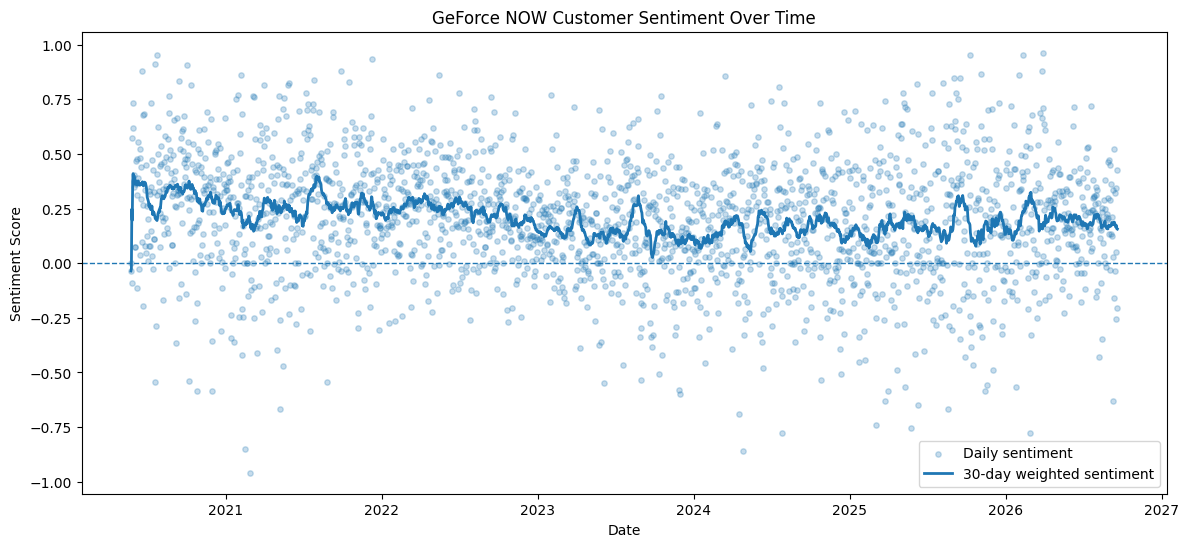

In [7]:
import matplotlib.pyplot as plt

reviews_daily = reviews_daily.sort_values("date")

# Weighted 30-day rolling sentiment
reviews_daily["sentiment_x_count"] = (
    reviews_daily["gfn_sentiment_score"] *
    reviews_daily["gfn_reviews_count"]
)

reviews_daily["sentiment_30d"] = (
    reviews_daily["sentiment_x_count"].rolling(30, min_periods=1).sum()
    /
    reviews_daily["gfn_reviews_count"].rolling(30, min_periods=1).sum()
)

plt.figure(figsize=(14, 6))

plt.scatter(
    reviews_daily["date"],
    reviews_daily["gfn_sentiment_score"],
    alpha=0.25,
    s=15,
    label="Daily sentiment"
)

plt.plot(
    reviews_daily["date"],
    reviews_daily["sentiment_30d"],
    linewidth=2,
    label="30-day weighted sentiment"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("GeForce NOW Customer Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()
plt.show()

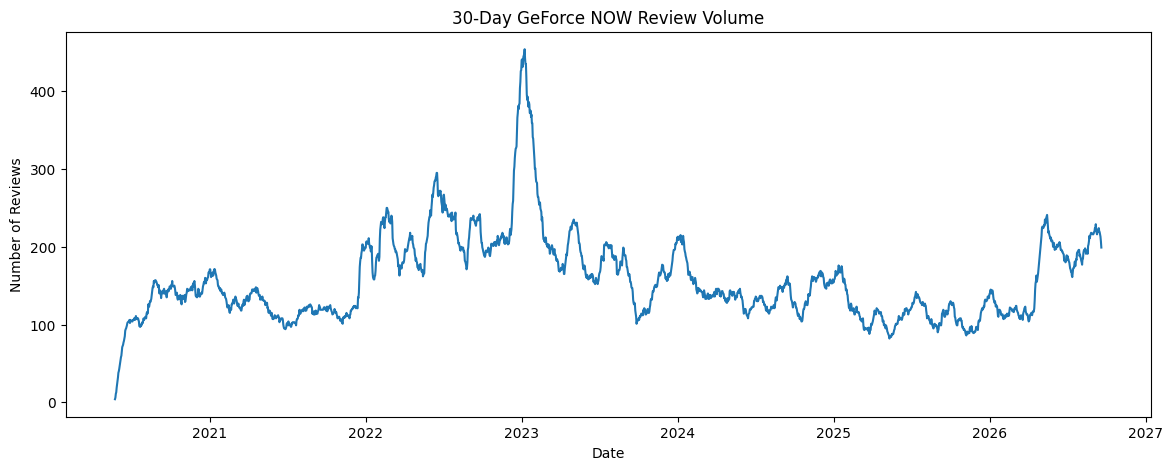

In [8]:
reviews_daily["reviews_30d"] = (
    reviews_daily["gfn_reviews_count"]
    .rolling(30, min_periods=1)
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    reviews_daily["date"],
    reviews_daily["reviews_30d"]
)

plt.title("30-Day GeForce NOW Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()

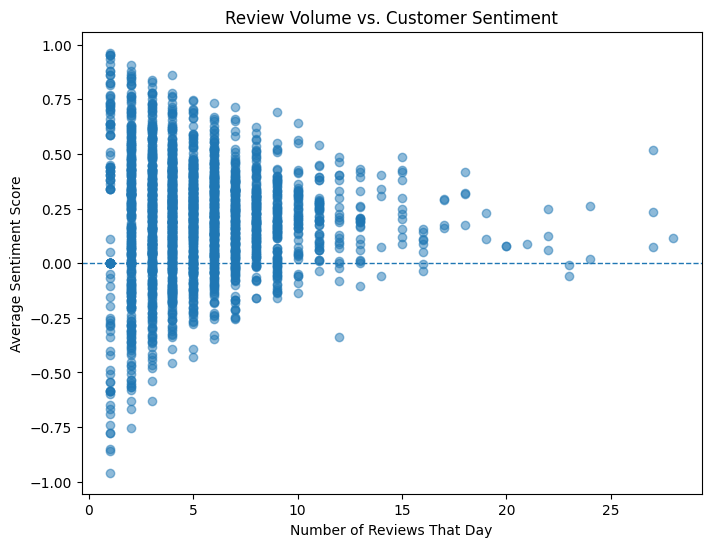

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    reviews_daily["gfn_reviews_count"],
    reviews_daily["gfn_sentiment_score"],
    alpha=0.5
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Review Volume vs. Customer Sentiment")
plt.xlabel("Number of Reviews That Day")
plt.ylabel("Average Sentiment Score")
plt.show()

In [10]:
sentiment_features = [
    "gfn_reviews_count",
    "gfn_avg_rating",
    "gfn_sentiment_score",
    "gfn_negative_share",
    "gfn_positive_share",
    "gfn_one_star_share"
]

correlations = (
    reviews_daily[sentiment_features]
    .corr()
    .round(2)
)

display(correlations)

,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_negative_share,gfn_positive_share,gfn_one_star_share
gfn_reviews_count,1.00,-0.01,0.00,-0.04,-0.00,-0.00
gfn_avg_rating,-0.01,1.00,0.54,-0.44,0.52,-0.89
gfn_sentiment_score,0.00,0.54,1.00,-0.79,0.86,-0.50
gfn_negative_share,-0.04,-0.44,-0.79,1.00,-0.65,0.39
gfn_positive_share,-0.00,0.52,0.86,-0.65,1.00,-0.48
gfn_one_star_share,-0.00,-0.89,-0.50,0.39,-0.48,1.00


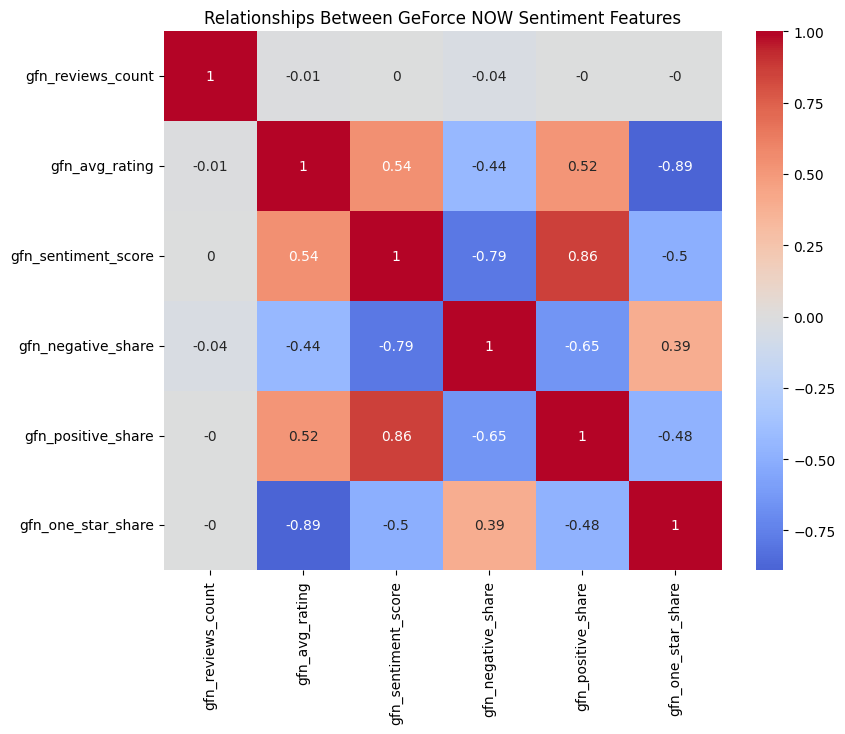

In [11]:
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlations,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Relationships Between GeForce NOW Sentiment Features")
plt.show()

In [12]:
display(
    reviews_daily[
        [
            "date",
            "gfn_reviews_count",
            "gfn_avg_rating",
            "gfn_sentiment_score",
            "gfn_negative_share",
            "gfn_one_star_share"
        ]
    ]
    .sort_values("gfn_sentiment_score")
    .head(20)
)

,date,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_negative_share,gfn_one_star_share
2248,2021-02-26,1,1.000000,-0.95900,1.0,1.000000
3402,2024-04-25,1,1.000000,-0.85750,1.0,1.000000
2237,2021-02-15,1,2.000000,-0.85190,1.0,0.000000
3493,2024-07-25,1,1.000000,-0.77940,1.0,1.000000
4074,2026-02-26,1,1.000000,-0.77830,1.0,1.000000
3795,2025-05-23,2,1.500000,-0.75425,1.0,0.500000
3713,2025-03-02,1,5.000000,-0.73980,1.0,0.000000
3393,2024-04-16,1,1.000000,-0.68870,1.0,1.000000
3883,2025-08-19,1,2.000000,-0.66640,1.0,0.000000
2319,2021-05-08,2,1.500000,-0.66510,1.0,0.500000


In [13]:
display(
    reviews_daily[
        [
            "date",
            "gfn_reviews_count",
            "gfn_avg_rating",
            "gfn_sentiment_score",
            "gfn_positive_share"
        ]
    ]
    .sort_values("gfn_sentiment_score", ascending=False)
    .head(20)
)

,date,gfn_reviews_count,gfn_avg_rating,gfn_sentiment_score,gfn_positive_share
4106,2026-03-30,1,5.000000,0.963300,1.0
2031,2020-07-24,1,4.000000,0.955100,1.0
4057,2026-02-09,1,2.000000,0.954700,1.0
3933,2025-10-08,1,5.000000,0.951300,1.0
2534,2021-12-09,1,5.000000,0.934900,1.0
2027,2020-07-20,1,5.000000,0.910100,1.0
2101,2020-10-02,2,5.000000,0.906000,1.0
2461,2021-09-27,2,4.500000,0.880900,1.0
4102,2026-03-26,1,1.000000,0.880200,1.0
1996,2020-06-19,1,3.000000,0.877900,1.0


In [14]:
reviews_daily["review_volume_zscore"] = (
    reviews_daily["gfn_reviews_count"]
    - reviews_daily["gfn_reviews_count"].mean()
) / reviews_daily["gfn_reviews_count"].std()

interesting_days = reviews_daily[
    (reviews_daily["review_volume_zscore"] > 2) &
    (reviews_daily["gfn_sentiment_score"] < 0)
]

display(
    interesting_days[
        [
            "date",
            "gfn_reviews_count",
            "gfn_sentiment_score",
            "gfn_avg_rating",
            "gfn_negative_share",
            "gfn_one_star_share"
        ]
    ].sort_values("gfn_reviews_count", ascending=False)
)

,date,gfn_reviews_count,gfn_sentiment_score,gfn_avg_rating,gfn_negative_share,gfn_one_star_share
2796,2022-08-28,23,-0.008935,1.782609,0.130435,0.608696
3115,2023-07-13,23,-0.058348,2.434783,0.521739,0.521739
4096,2026-03-20,16,-0.002506,1.750000,0.375000,0.625000
2916,2022-12-26,16,-0.036500,2.312500,0.437500,0.625000
2914,2022-12-24,14,-0.057036,2.500000,0.428571,0.500000
2913,2022-12-23,13,-0.103431,2.000000,0.384615,0.538462
2970,2023-02-18,12,-0.079583,1.833333,0.583333,0.750000
3160,2023-08-27,12,-0.021358,2.583333,0.416667,0.500000
3300,2024-01-14,12,-0.336233,1.916667,0.666667,0.583333
4251,2026-08-22,12,-0.001133,3.166667,0.416667,0.333333


## Build true Calendar-Window Features

In [15]:
# Sort the complete daily dataset by date
df_analysis = df_analysis.sort_values("date").copy()

# Total sentiment contribution on each day
# A day with 10 reviews should carry more weight than a day with 1 review
df_analysis["sentiment_x_count"] = (
    df_analysis["gfn_sentiment_score"].fillna(0)
    * df_analysis["gfn_reviews_count"]
)

# -----------------------------
# Review volume features
# -----------------------------

df_analysis["reviews_7d"] = (
    df_analysis["gfn_reviews_count"]
    .rolling(7, min_periods=1)
    .sum()
)

df_analysis["reviews_30d"] = (
    df_analysis["gfn_reviews_count"]
    .rolling(30, min_periods=1)
    .sum()
)

# -----------------------------
# Weighted sentiment features
# -----------------------------

df_analysis["sentiment_7d"] = (
    df_analysis["sentiment_x_count"].rolling(7, min_periods=1).sum()
    /
    df_analysis["gfn_reviews_count"].rolling(7, min_periods=1).sum()
)

df_analysis["sentiment_30d"] = (
    df_analysis["sentiment_x_count"].rolling(30, min_periods=1).sum()
    /
    df_analysis["gfn_reviews_count"].rolling(30, min_periods=1).sum()
)

display(
    df_analysis[
        [
            "date",
            "gfn_reviews_count",
            "gfn_sentiment_score",
            "reviews_7d",
            "reviews_30d",
            "sentiment_7d",
            "sentiment_30d"
        ]
    ].tail(20)
)

,date,gfn_reviews_count,gfn_sentiment_score,reviews_7d,reviews_30d,sentiment_7d,sentiment_30d
4260,2026-08-31,6,0.135117,50.0,216.0,0.262840,0.168366
4261,2026-09-01,3,0.290200,41.0,217.0,0.283246,0.168499
4262,2026-09-02,7,-0.030286,40.0,219.0,0.240078,0.168865
4263,2026-09-03,2,0.449600,36.0,220.0,0.241806,0.172185
4264,2026-09-04,6,0.131467,34.0,224.0,0.230432,0.170152
4265,2026-09-05,10,0.363660,39.0,223.0,0.234713,0.176875
4266,2026-09-06,9,0.212411,43.0,229.0,0.202456,0.186240
4267,2026-09-07,4,0.124725,41.0,222.0,0.204727,0.184544
4268,2026-09-08,3,-0.632600,41.0,218.0,0.137205,0.175529
4269,2026-09-09,4,0.336775,38.0,216.0,0.189066,0.178866


## Engineer Sentiment Shifts

In [16]:
# Compare short-term sentiment with the longer-term baseline

df_analysis["sentiment_shift"] = (
    df_analysis["sentiment_7d"]
    - df_analysis["sentiment_30d"]
)

# Average rating: short-term vs longer-term
df_analysis["rating_7d"] = (
    (
        df_analysis["gfn_avg_rating"].fillna(0)
        * df_analysis["gfn_reviews_count"]
    )
    .rolling(7, min_periods=1)
    .sum()
    /
    df_analysis["gfn_reviews_count"]
    .rolling(7, min_periods=1)
    .sum()
)

df_analysis["rating_30d"] = (
    (
        df_analysis["gfn_avg_rating"].fillna(0)
        * df_analysis["gfn_reviews_count"]
    )
    .rolling(30, min_periods=1)
    .sum()
    /
    df_analysis["gfn_reviews_count"]
    .rolling(30, min_periods=1)
    .sum()
)

df_analysis["rating_shift"] = (
    df_analysis["rating_7d"]
    - df_analysis["rating_30d"]
)

display(
    df_analysis[
        [
            "date",
            "sentiment_7d",
            "sentiment_30d",
            "sentiment_shift",
            "rating_7d",
            "rating_30d",
            "rating_shift"
        ]
    ].tail(20)
)

,date,sentiment_7d,sentiment_30d,sentiment_shift,rating_7d,rating_30d,rating_shift
4260,2026-08-31,0.262840,0.168366,0.094474,2.920000,2.888889,0.031111
4261,2026-09-01,0.283246,0.168499,0.114747,2.975610,2.866359,0.109250
4262,2026-09-02,0.240078,0.168865,0.071212,3.225000,2.885845,0.339155
4263,2026-09-03,0.241806,0.172185,0.069621,3.083333,2.877273,0.206061
4264,2026-09-04,0.230432,0.170152,0.060280,3.000000,2.897321,0.102679
4265,2026-09-05,0.234713,0.176875,0.057838,3.051282,2.914798,0.136484
4266,2026-09-06,0.202456,0.186240,0.016216,3.116279,2.969432,0.146847
4267,2026-09-07,0.204727,0.184544,0.020183,3.121951,2.972973,0.148978
4268,2026-09-08,0.137205,0.175529,-0.038324,3.219512,2.954128,0.265384
4269,2026-09-09,0.189066,0.178866,0.010200,3.052632,2.962963,0.089669


## Engineer a review-volume anomaly

In [17]:
# Recent baseline for daily review activity

df_analysis["review_count_30d_mean"] = (
    df_analysis["gfn_reviews_count"]
    .rolling(30, min_periods=7)
    .mean()
)

df_analysis["review_count_30d_std"] = (
    df_analysis["gfn_reviews_count"]
    .rolling(30, min_periods=7)
    .std()
)

df_analysis["review_volume_anomaly"] = (
    (
        df_analysis["gfn_reviews_count"]
        - df_analysis["review_count_30d_mean"]
    )
    /
    df_analysis["review_count_30d_std"]
)

display(
    df_analysis[
        [
            "date",
            "gfn_reviews_count",
            "review_count_30d_mean",
            "review_volume_anomaly"
        ]
    ]
    .sort_values("review_volume_anomaly", ascending=False)
    .head(20)
)

,date,gfn_reviews_count,review_count_30d_mean,review_volume_anomaly
2796,2022-08-28,23,6.533333,4.414697
4096,2026-03-20,16,3.733333,4.357000
3115,2023-07-13,23,6.733333,4.084902
2590,2022-02-03,27,7.000000,4.019451
2542,2021-12-17,24,5.133333,3.836107
2695,2022-05-19,17,5.933333,3.740356
2696,2022-05-20,22,6.433333,3.736392
2504,2021-11-09,10,3.266667,3.665318
2539,2021-12-14,16,4.333333,3.587670
2402,2021-07-30,12,3.566667,3.575126


## Announcement event study — protocol and calendar validation

**Question:** In this collected GeForce NOW app-review sample, do review-weighted text sentiment, star ratings, and review activity change around independently documented NVIDIA/GeForce NOW announcements?

This is a **retrospective, exploratory before/after study**, not a causal or forecasting model. The preceding EDA is preserved. This section starts from `df_analysis`, not the days-with-reviews-only dataframe. It does **not** use the earlier rolling `sentiment_shift`, `rating_shift`, or same-day-inclusive volume z-score as an announcement effect.

Default comparison: calendar days **-14 through -1** versus **+1 through +14**. Day 0 is stored separately but excluded from the before/after comparison because within-day ordering and review time zones are not documented. `MIN_REVIEWS = 20` on each side is a transparent screening heuristic, not a guarantee of statistical reliability. No-review dates in the supplied sample are not filled with neutral sentiment.

Primary outcome: the change in review-weighted mean text sentiment. Ratings, one-star share, negative share, and review volume are corroborating/descriptive measures. Windows and the catalogue are fixed before calculating these event-specific differences. Prior EDA has already been viewed, so this is not a preregistered confirmatory analysis.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WINDOW = 14          # Compare days -14:-1 with days +1:+14
MIN_REVIEWS = 20      # Screening rule per side, not a significance threshold
OUT = Path("../data/processed/event_study")
OUT.mkdir(parents=True, exist_ok=True)

METRICS = {
    "sentiment": "gfn_sentiment_score",
    "rating": "gfn_avg_rating",
    "negative_share": "gfn_negative_share",
    "one_star_share": "gfn_one_star_share",
}

# Use the full calendar timeline, NOT reviews_daily.
daily = df_analysis[["date", "gfn_reviews_count", *METRICS.values()]].copy()
daily["date"] = pd.to_datetime(daily["date"]).dt.normalize()
daily = daily.sort_values("date").set_index("date")

assert not daily.index.has_duplicates, "Duplicate dates need investigation."
assert daily.index.equals(pd.date_range(daily.index.min(), daily.index.max())), (
    "Calendar dates are missing. Investigate rather than inventing zero-review days."
)
assert daily["gfn_reviews_count"].notna().all()
assert daily["gfn_reviews_count"].ge(0).all()
assert not daily.loc[
    daily["gfn_reviews_count"].gt(0), list(METRICS.values())
].isna().any().any(), "Some reviewed days lack a required metric."

print(f"{len(daily):,} calendar days; {daily.gfn_reviews_count.sum():,} reviews")
print(daily.index.min().date(), "to", daily.index.max().date())

2,310 calendar days; 12,008 reviews
2020-05-24 to 2026-09-19


## Source-verified announcement catalogue

The catalogue is a **curated pilot, not an exhaustive inventory of every NVIDIA launch**. It covers major paid-membership/cloud-GPU changes, selected CES/Gamescom product bundles, and desktop GPU-generation announcements for context. Routine weekly game additions, earnings, stock splits, regional server rollouts, temporary promotions, and unrelated enterprise AI launches are outside this pilot.

Dates come from NVIDIA's dated primary publications. Store the original announcement date, not a later recap or implementation date. Product bundles share a single observation: in particular, **2025-01-06** contains both GFN platform news and RTX 50-series hardware news. NVIDIA-hardware rows are contextual comparisons, **not untreated controls**.

Sources are retained as `source_url` and, where relevant, `source_url_2`. `notes` records known limitations: membership upgrades may be bundled with policies, CES may contain multiple simultaneous announcements, and the 2026 events have nearby service changes. Excluding overlap between this catalogue's windows does not establish absence of other news.

In [19]:
# Curated pilot catalogue; selected from product records, not review spikes.
# Same-day bundles are one event, not multiple independent observations.
B = "https://blogs.nvidia.com/blog/"
N = "https://nvidianews.nvidia.com/news/"
G = "https://www.nvidia.com/en-us/geforce/news/"

events = pd.DataFrame([
    ('rtx30', '2020-09-01', 'NVIDIA hardware', 'gpu_generation',
     'RTX 30 series', N + 'nvidia-delivers-greatest-ever-generational-leap-in-performance-with-geforce-rtx-30-series-gpus'),
    ('priority', '2021-03-18', 'GFN', 'membership',
     'Priority membership', B + 'geforce-now-priority/'),
    ('gfn3080', '2021-10-21', 'GFN', 'cloud_gpu',
     'RTX 3080 cloud tier', N + 'nvidia-introduces-the-next-generation-in-cloud-gaming'),
    ('rtx40', '2022-09-20', 'NVIDIA hardware', 'gpu_generation',
     'RTX 40 series', N + 'nvidia-delivers-quantum-leap-in-performance-introduces-new-era-of-neural-rendering-with-geforce-rtx-40-series'),
    ('ultimate', '2023-01-03', 'GFN', 'cloud_gpu',
     'Ultimate / RTX 4080', N + 'nvidia-brings-rtx-4080-to-geforce-now'),
    ('daypasses', '2024-01-08', 'GFN', 'membership_features',
     'Day Passes + G-SYNC (CES)', B + 'ces-2024-geforce-now-activision-blizzard-day-passes-g-sync/'),
    ('performance', '2024-11-07', 'GFN', 'membership_policy',
     'Performance + playtime policy', B + 'geforce-now-thursday-performance-membership/'),
    ('ces2025', '2025-01-06', 'GFN', 'platform_bundle',
     'Steam Deck / VR + RTX 50 (CES)', B + 'geforce-now-ces-2025/'),
    ('gfn5080', '2025-08-18', 'GFN', 'cloud_gpu',
     'RTX 5080 + Install-to-Play', N + 'nvidia-blackwell-architecture-comes-to-geforce-now'),
    ('ces2026', '2026-01-05', 'GFN', 'platform_bundle',
     'Linux / Fire TV (CES)', B + 'geforce-now-ces-2026/'),
    ('gamescom2026', '2026-08-25', 'GFN', 'feature_platform_bundle',
     'DLSS / device expansion (Gamescom)', G + 'gamescom-2026-nvidia-geforce-rtx-dlss-4-5-announcements/'),
], columns=["event_id", "event_date", "group", "event_type",
            "event_name", "source_url"])

events["event_date"] = pd.to_datetime(events["event_date"])
events["verified_on"] = "2026-09-20"
events["date_basis"] = "Official announcement publication date (day-level)"
events["notes"] = events["event_id"].map(
    {
        "rtx30": "Hardware context, not an untreated control; includes a GeForce NOW promotional bundle.",
        "priority": "New membership pricing plus Founders-for-Life and streaming-client updates.",
        "gfn3080": "Announcement/preorders; regional activation followed in November/December.",
        "rtx40": "Hardware context, not an untreated control; broader GeForce Beyond announcements.",
        "ultimate": "CES announcement bundle; not the later server-rollout date.",
        "daypasses": "Announcement, not later Day Pass availability; games and streaming updates bundled.",
        "performance": "Performance upgrade and future 100-hour policy announced together; cannot isolate either.",
        "ces2025": "GFN platform expansion and RTX 50 hardware announced the same date; counted once.",
        "gfn5080": "Original announcement; not August 21 recap or September 10 rollout.",
        "ces2026": "CES bundle; also near the January 2026 transition in previously announced playtime limits.",
        "gamescom2026": "Original Gamescom publication, not August 27 recap; nearby Linux/Firefox updates are confounders."
    }
)
events["source_url_2"] = ""
events.loc[events.event_id.eq("ces2025"), "source_url_2"] = (
    N + "nvidia-blackwell-geforce-rtx-50-series-opens-new-world-of-ai-computer-graphics"
)

assert events["event_id"].is_unique
assert events["event_date"].is_unique, "Combine same-day announcements."
display(events[["event_date", "event_name", "group", "event_type"]])

,event_date,event_name,group,event_type
0,2020-09-01,RTX 30 series,NVIDIA hardware,gpu_generation
1,2021-03-18,Priority membership,GFN,membership
2,2021-10-21,RTX 3080 cloud tier,GFN,cloud_gpu
3,2022-09-20,RTX 40 series,NVIDIA hardware,gpu_generation
4,2023-01-03,Ultimate / RTX 4080,GFN,cloud_gpu
5,2024-01-08,Day Passes + G-SYNC (CES),GFN,membership_features
6,2024-11-07,Performance + playtime policy,GFN,membership_policy
7,2025-01-06,Steam Deck / VR + RTX 50 (CES),GFN,platform_bundle
8,2025-08-18,RTX 5080 + Install-to-Play,GFN,cloud_gpu
9,2026-01-05,Linux / Fire TV (CES),GFN,platform_bundle


## Review-weighted, fixed-baseline event summaries

A window mean is `sum(daily_mean * daily_review_count) / sum(daily_review_count)`. This gives each observed review equal weight within a window rather than giving a one-review day the same weight as a twenty-review day.

`delta_sentiment` and `delta_rating` are post minus pre. Share changes are **fractions**: multiply by 100 for percentage points. `volume_ratio` is post-review count divided by pre-review count; both windows contain 14 calendar days.

Keep ineligible events in the audit table, but do not pool incomplete, too-sparse, or overlapping catalogued windows.

In [20]:
def window_stats(frame):
    """Review-weighted averages; absent sentiment is never replaced with zero."""
    result = {"reviews": int(frame["gfn_reviews_count"].sum())}
    for metric, column in METRICS.items():
        valid = frame[column].notna() & frame["gfn_reviews_count"].gt(0)
        weights = frame.loc[valid, "gfn_reviews_count"]
        result[metric] = (
            np.average(frame.loc[valid, column], weights=weights)
            if weights.sum() > 0 else np.nan
        )
    return result

def compare_at(anchor, window=WINDOW):
    """Before/after comparison excluding the announcement's calendar date."""
    anchor = pd.Timestamp(anchor)
    pre = daily.reindex(pd.date_range(
        anchor - pd.Timedelta(days=window), anchor - pd.Timedelta(days=1)
    ))
    post = daily.reindex(pd.date_range(
        anchor + pd.Timedelta(days=1), anchor + pd.Timedelta(days=window)
    ))
    before, after = window_stats(pre), window_stats(post)
    result = {f"pre_{key}": value for key, value in before.items()}
    result.update({f"post_{key}": value for key, value in after.items()})
    result.update({f"delta_{key}": after[key] - before[key] for key in METRICS})
    result["volume_ratio"] = (
        after["reviews"] / before["reviews"] if before["reviews"] else np.nan
    )
    result["full_window"] = (
        pre["gfn_reviews_count"].notna().all()
        and post["gfn_reviews_count"].notna().all()
    )
    result["enough_reviews"] = min(before["reviews"], after["reviews"]) >= MIN_REVIEWS
    return result

summary = pd.concat([
    events.reset_index(drop=True),
    pd.DataFrame([compare_at(date) for date in events["event_date"]])
], axis=1)

# Flag reused calendar windows instead of treating them as independent evidence.
dates = events["event_date"].to_numpy()
distance = abs(dates[:, None] - dates[None, :])
overlap = (
    (distance <= np.timedelta64(2 * WINDOW, "D"))
    & ~np.eye(len(events), dtype=bool)
)
summary["overlaps_catalogued_window"] = overlap.any(axis=1)
summary["eligible"] = (
    summary["full_window"] & summary["enough_reviews"]
    & ~summary["overlaps_catalogued_window"]
)

primary = summary[summary["eligible"] & summary["group"].eq("GFN")].copy()
assert len(primary) >= 2, "Too few eligible events for an aggregate comparison."

display(summary[[
    "event_date", "event_name", "pre_reviews", "post_reviews",
    "delta_sentiment", "delta_rating", "volume_ratio", "eligible"
]].round(3))
print("Eligible GFN announcements:", len(primary))

,event_date,event_name,pre_reviews,post_reviews,delta_sentiment,delta_rating,volume_ratio,eligible
0,2020-09-01,RTX 30 series,61,73,-0.060,-0.351,1.197,True
1,2021-03-18,Priority membership,48,74,0.079,-0.198,1.542,True
2,2021-10-21,RTX 3080 cloud tier,50,40,0.134,-0.230,0.800,True
3,2022-09-20,RTX 40 series,85,93,-0.039,-0.303,1.094,True
4,2023-01-03,Ultimate / RTX 4080,214,148,0.067,-0.212,0.692,True
5,2024-01-08,Day Passes + G-SYNC (CES),98,71,-0.009,0.134,0.724,True
6,2024-11-07,Performance + playtime policy,68,77,-0.042,-0.395,1.132,True
7,2025-01-06,Steam Deck / VR + RTX 50 (CES),85,65,-0.061,-0.062,0.765,True
8,2025-08-18,RTX 5080 + Install-to-Play,50,35,0.048,-0.517,0.700,True
9,2026-01-05,Linux / Fire TV (CES),60,42,0.075,-0.090,0.700,True


Eligible GFN announcements: 9


## Long-format event-day dataset

`event_days` has one row per **event_id × event_day**. Offsets -28 to -15 provide earlier pre-event context. Offsets -14 to -1 define the fixed baseline; day 0 remains explicit; +1 to +14 are the post period.

The `abnormal_...` features mean **deviation from this event's fixed pre-period average**. The word “abnormal” does not mean statistically significant or causal. Do not treat all panel rows as independent observations; several rows belong to the same event.

In [21]:
# One row = one announcement x one relative calendar day.
offsets = pd.DataFrame({"event_day": np.arange(-28, WINDOW + 1)})
event_days = events.merge(offsets, how="cross")
event_days["date"] = (
    event_days["event_date"] + pd.to_timedelta(event_days["event_day"], unit="D")
)
event_days = event_days.merge(
    daily.reset_index(), on="date", how="left", validate="many_to_one"
)
event_days["period"] = np.select(
    [event_days["event_day"] < -WINDOW,
     event_days["event_day"] < 0,
     event_days["event_day"].eq(0)],
    ["earlier_pre", "pre", "announcement_day"], default="post"
)
event_days = event_days.merge(
    summary[["event_id", "eligible", *[f"pre_{key}" for key in METRICS]]],
    on="event_id", how="left", validate="many_to_one"
)
for metric, column in METRICS.items():
    event_days[f"abnormal_{metric}"] = (
        event_days[column] - event_days[f"pre_{metric}"]
    )

print("Event-day panel shape:", event_days.shape)
display(event_days.loc[event_days.event_id.eq("performance"), [
    "event_name", "date", "event_day", "period", "gfn_reviews_count",
    "gfn_sentiment_score", "pre_sentiment", "abnormal_sentiment"
]].head(8))

Event-day panel shape: (473, 27)


,event_name,date,event_day,period,gfn_reviews_count,gfn_sentiment_score,pre_sentiment,abnormal_sentiment
258,Performance + playtime policy,2024-10-10,-28,earlier_pre,5,0.316080,0.199401,0.116679
259,Performance + playtime policy,2024-10-11,-27,earlier_pre,6,0.227917,0.199401,0.028515
260,Performance + playtime policy,2024-10-12,-26,earlier_pre,2,0.000000,0.199401,-0.199401
261,Performance + playtime policy,2024-10-13,-25,earlier_pre,3,0.340200,0.199401,0.140799
262,Performance + playtime policy,2024-10-14,-24,earlier_pre,8,0.517537,0.199401,0.318136
263,Performance + playtime policy,2024-10-15,-23,earlier_pre,3,0.229800,0.199401,0.030399
264,Performance + playtime policy,2024-10-16,-22,earlier_pre,1,0.585900,0.199401,0.386499
265,Performance + playtime policy,2024-10-17,-21,earlier_pre,4,0.045025,0.199401,-0.154376


## Visual 1 — event-specific changes, with rating corroboration

Show every eligible GFN event, not only the largest change. Use separate figures because text sentiment units and rating points are different scales. Positive bars indicate a higher measured value after the announcement; negative bars indicate a lower value.

The dates represent announcement bundles. A change cannot automatically be attributed to one component of a bundle.

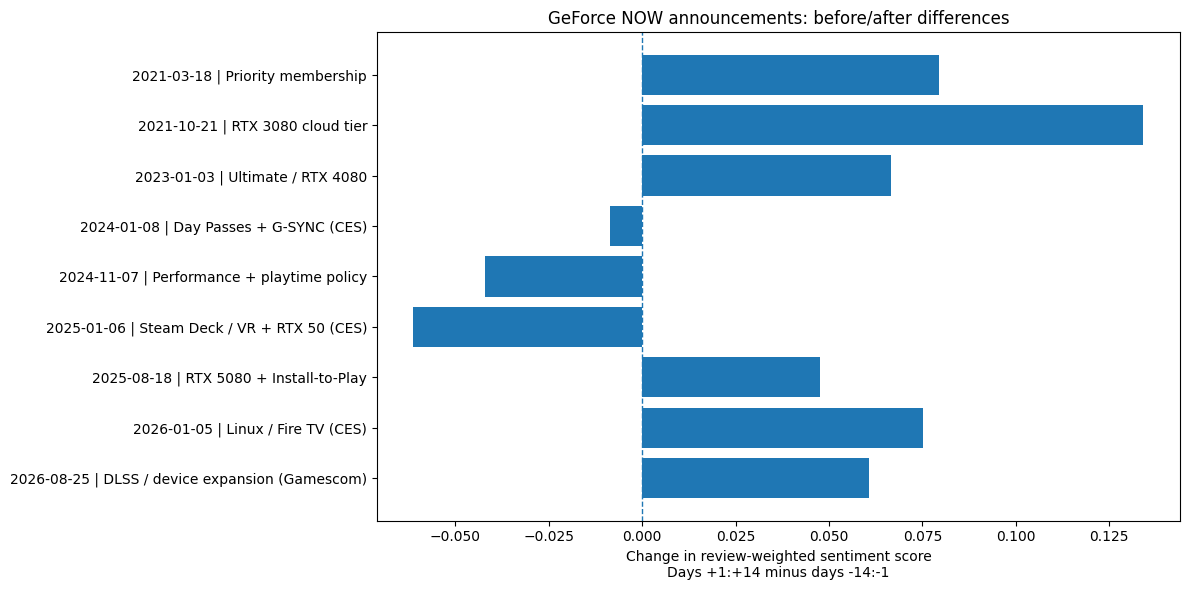

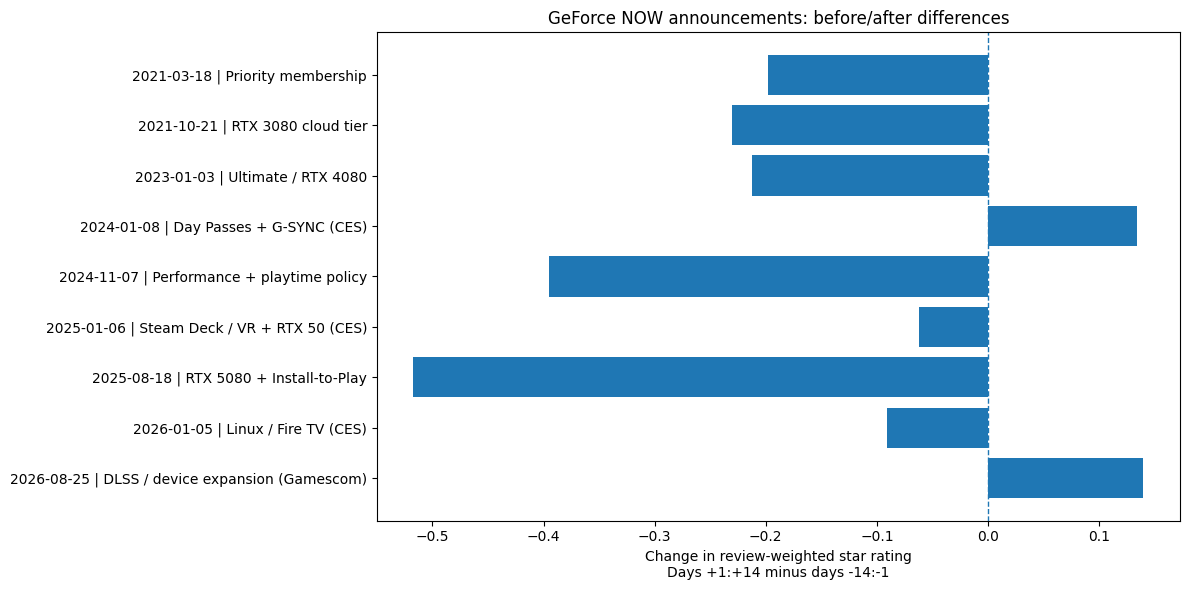

In [22]:
# Separate charts: rating points and sentiment units are not interchangeable.
plot_data = primary.sort_values("event_date")
labels = (
    plot_data["event_date"].dt.strftime("%Y-%m-%d")
    + " | " + plot_data["event_name"]
)

for metric, xlabel in [
    ("sentiment", "Change in review-weighted sentiment score"),
    ("rating", "Change in review-weighted star rating")
]:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(labels, plot_data[f"delta_{metric}"])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel + "\nDays +1:+14 minus days -14:-1")
    ax.set_title("GeForce NOW announcements: before/after differences")
    fig.tight_layout()
    fig.savefig(OUT / f"event_changes_{metric}.png", dpi=160, bbox_inches="tight")
    plt.show()

## Visual 2 — announcement-aligned sentiment trajectory

Each seven-day bin is review-weighted within event. The plotted mean gives every selected announcement equal weight, avoiding dominance by a high-volume event. The pointwise band resamples whole event trajectories, not individual days.

The band is descriptive variation across a small, curated set of heterogeneous events. It is **not** a multiple-comparison-adjusted confidence band, a counterfactual, or evidence that an announcement caused a change. Baseline bins are partly constrained by the construction of the fixed pre-period average.

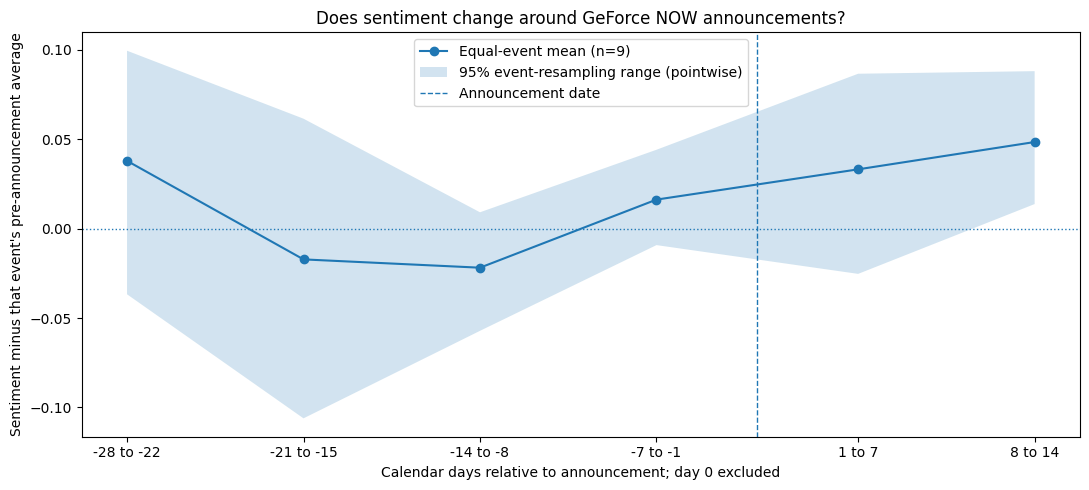

In [23]:
# Non-overlapping seven-day bins; no rolling window crosses day zero.
BINS = [(-28, -22), (-21, -15), (-14, -8), (-7, -1), (1, 7), (8, 14)]
rows = []
selected = event_days[event_days["event_id"].isin(primary["event_id"])]

for event_id, frame in selected.groupby("event_id"):
    for start, end in BINS:
        stats = window_stats(frame[frame["event_day"].between(start, end)])
        rows.append({
            "event_id": event_id,
            "bin_start": start, "bin_end": end, "bin_mid": (start + end) / 2,
            **stats,
            "sentiment_deviation": stats["sentiment"] - frame["pre_sentiment"].iloc[0]
        })

event_bins = pd.DataFrame(rows)
wide = event_bins.pivot(
    index="event_id", columns="bin_mid", values="sentiment_deviation"
).sort_index(axis=1)

# A fixed cohort across every plotted bin avoids changing composition.
wide = wide.dropna()
assert len(wide) >= 2, "Insufficient complete event trajectories."
rng = np.random.default_rng(510)
samples = rng.integers(0, len(wide), size=(5000, len(wide)))
resampled_means = wide.to_numpy()[samples].mean(axis=1)
low, high = np.quantile(resampled_means, [0.025, 0.975], axis=0)
mean = wide.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(wide.columns, mean, marker="o", label=f"Equal-event mean (n={len(wide)})")
ax.fill_between(wide.columns, low, high, alpha=0.2,
                label="95% event-resampling range (pointwise)")
ax.axvline(0, linestyle="--", linewidth=1, label="Announcement date")
ax.axhline(0, linestyle=":", linewidth=1)
ax.set_xticks([(a + b) / 2 for a, b in BINS])
ax.set_xticklabels([f"{a} to {b}" for a, b in BINS])
ax.set_xlabel("Calendar days relative to announcement; day 0 excluded")
ax.set_ylabel("Sentiment minus that event's pre-announcement average")
ax.set_title("Does sentiment change around GeForce NOW announcements?")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "event_time_sentiment.png", dpi=160, bbox_inches="tight")
plt.show()

# This range describes variation across the selected events, not a causal test.

## Visual 3 — matched-date placebo comparison

Ask whether changes of the observed magnitude also occur on other nearby dates. Candidate anchors have the same weekday and lie within 26 weeks of each real event. Require the same coverage/count rules. Exclude candidate windows overlapping any catalogued event's -14/+14 window, and reject simulated schedules that reuse dates.

The primary comparison is the **mean absolute sentiment change**, because the question is whether announcements coincide with shifts in either direction. A signed mean alone can hide offsetting positive and negative responses. The printed exceedance is a **descriptive comparison fraction**, not a randomized-experiment p-value. Nearby dates are not proven event-free; holidays, trends, outages, other product news, and incomplete event coverage remain possible confounders.

Observed mean absolute sentiment change: 0.0639
Median matched-comparison change: 0.0691
Comparison schedules equally/larger: 62.1%


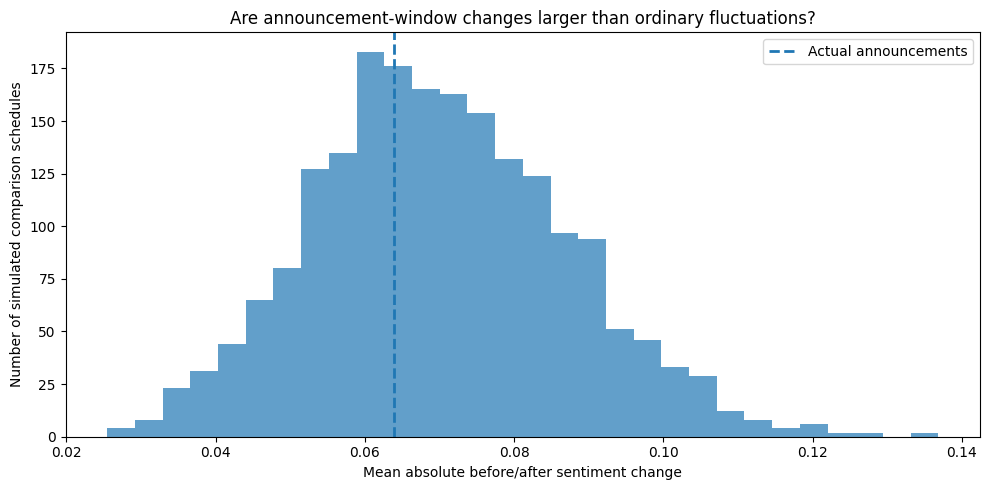

,event_name,delta_sentiment,delta_rating,n_placebo_dates,placebo_equal_or_larger_pct
0,RTX 30 series,-0.060,-0.351,28,64.286
1,Priority membership,0.079,-0.198,42,47.619
2,RTX 3080 cloud tier,0.134,-0.230,44,13.636
3,RTX 40 series,-0.039,-0.303,35,74.286
4,Ultimate / RTX 4080,0.067,-0.212,35,45.714
5,Day Passes + G-SYNC (CES),-0.009,0.134,44,93.182
6,Performance + playtime policy,-0.042,-0.395,36,55.556
7,Steam Deck / VR + RTX 50 (CES),-0.061,-0.062,36,44.444
8,RTX 5080 + Install-to-Play,0.048,-0.517,35,57.143
9,Linux / Fire TV (CES),0.075,-0.090,35,42.857


In [24]:
# Are equally large changes common around nearby comparison dates?
# Match the weekday, stay within +/-26 weeks, and exclude any comparison
# window overlapping a catalogued event's -14/+14 analysis window.
placebo_pools = {}
audit_rows = []
for event in summary.itertuples():
    rows = []
    for weeks in range(-26, 27):
        if weeks == 0:
            continue
        anchor = event.event_date + pd.Timedelta(weeks=weeks)
        if ((events["event_date"] - anchor).abs().dt.days <= 2 * WINDOW).any():
            continue
        stats = compare_at(anchor)
        if stats["full_window"] and stats["enough_reviews"]:
            rows.append({"event_id": event.event_id, "placebo_date": anchor, **stats})
    pool = pd.DataFrame(rows)
    placebo_pools[event.event_id] = pool
    audit_rows.append({
        "event_id": event.event_id,
        "n_placebo_dates": len(pool),
        "placebo_equal_or_larger_pct": (
            100 * pool["delta_sentiment"].abs().ge(abs(event.delta_sentiment)).mean()
            if len(pool) else np.nan
        )
    })

summary = summary.drop(
    columns=["n_placebo_dates", "placebo_equal_or_larger_pct"], errors="ignore"
).merge(pd.DataFrame(audit_rows), on="event_id", validate="one_to_one")

# Each simulated schedule has one comparison date per GFN event.
# Reject entire schedules whose windows reuse calendar dates.
rng = np.random.default_rng(510)
pools = [placebo_pools[event_id] for event_id in primary["event_id"]]
assert all(len(pool) >= 10 for pool in pools), "Too few local comparison dates."
placebo_strength = []
for _ in range(2000 * 100):
    draws = [pool.iloc[rng.integers(len(pool))] for pool in pools]
    selected_dates = np.sort(np.array(
        [row["placebo_date"] for row in draws], dtype="datetime64[ns]"
    ))
    if (np.diff(selected_dates) <= np.timedelta64(2 * WINDOW, "D")).any():
        continue
    placebo_strength.append(np.mean([abs(row["delta_sentiment"]) for row in draws]))
    if len(placebo_strength) == 2000:
        break
assert len(placebo_strength) == 2000, "Not enough non-overlapping schedules."

placebo_strength = np.array(placebo_strength)
observed_strength = primary["delta_sentiment"].abs().mean()
exceedance = np.mean(placebo_strength >= observed_strength)
print(f"Observed mean absolute sentiment change: {observed_strength:.4f}")
print(f"Median matched-comparison change: {np.median(placebo_strength):.4f}")
print(f"Comparison schedules equally/larger: {exceedance:.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(placebo_strength, bins=30, alpha=0.7)
ax.axvline(observed_strength, linestyle="--", linewidth=2,
           label="Actual announcements")
ax.set_xlabel("Mean absolute before/after sentiment change")
ax.set_ylabel("Number of simulated comparison schedules")
ax.set_title("Are announcement-window changes larger than ordinary fluctuations?")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "placebo_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

display(summary[[
    "event_name", "delta_sentiment", "delta_rating",
    "n_placebo_dates", "placebo_equal_or_larger_pct"
]].round(3))
# Descriptive placebo comparison, NOT a randomized experiment or causal p-value.

## Review-text and sentiment-label audit

A numeric score should not be treated as ground truth. Quantify disagreement with star ratings, then inspect text. Positive labels on one-star reviews do not by themselves measure classifier error: some reviews can be mixed or concern different aspects of the service.

The random pre/post sample below is centered on the Performance/policy bundle chosen explicitly for substantive relevance, not because it maximized an effect. Look for discussion of pricing, playtime, queues, crashes, devices, and the announced features. Do not infer exposure to the announcement from posting date alone. Author names are not needed for this analysis.

In [25]:
# Check whether the review text supports the interpretation of the score.
raw_reviews = pd.read_csv(
    "../data/geforcenow_app_reviews_raw.csv", parse_dates=["posted_at"]
).drop_duplicates("review_id")
raw_reviews["date"] = raw_reviews["posted_at"].dt.normalize()

one_star = raw_reviews["rating"].eq(1)
positive_one_star = one_star & raw_reviews["sentiment_category"].eq("Positive")
print(
    "1-star reviews labeled Positive:",
    f"{positive_one_star.sum():,}/{one_star.sum():,}",
    f"({positive_one_star.sum() / one_star.sum():.1%})"
)
display(raw_reviews.loc[positive_one_star, [
    "date", "review_text", "rating", "sentiment_score", "sentiment_category"
]].head(5))

# Select a policy/product bundle explicitly rather than cherry-picking the
# largest effect. Compare random text samples before versus after it.
focus_date = events.loc[events.event_id.eq("performance"), "event_date"].iloc[0]
relative_day = (raw_reviews["date"] - focus_date).dt.days
samples = []
for period, mask in [
    ("pre", relative_day.between(-WINDOW, -1)),
    ("post", relative_day.between(1, WINDOW))
]:
    subset = raw_reviews.loc[mask]
    samples.append(
        subset.sample(n=min(5, len(subset)), random_state=510).assign(period=period)
    )
text_audit = pd.concat(samples)
with pd.option_context("display.max_colwidth", 180):
    display(text_audit[[
        "period", "date", "review_text", "rating", "sentiment_score"
    ]])
# Disagreement is not itself an error-rate estimate; manually assess context.

1-star reviews labeled Positive: 1,273/4,741 (26.9%)


,date,review_text,rating,sentiment_score,sentiment_category
3,2026-09-18,doesn't login. waste of time and money. fix th...,1,0.3252,Positive
9,2026-09-17,true no security main account banned lD today ...,1,0.6652,Positive
12,2026-09-16,Low security level. I have experienced several...,1,0.7430,Positive
24,2026-09-14,"Doesn't work, it rejected my account",1,0.4023,Positive
42,2026-09-12,this app will give you malware and viruses do ...,1,0.5106,Positive


,period,date,review_text,rating,sentiment_score
3130,pre,2024-10-26,"I already had a hard time signing in on PC, but on mobile? OH, VERY MUCH. Whenever I try logging in, I keep seeing ""Login Failed"" LIKE WHAT IS THAT SUPPOSED TO MEAN??? THE SERV...",1,-0.7059
3084,pre,2024-11-04,Please do it with less internet because I need to do it faster,5,0.3182
3086,pre,2024-11-04,Even with an oled and excellent wifi.. I paid for the best subscription and still I lag like crazy playing fast games. It's terrible. Should be free for how bad it plays at ult...,1,0.7269
3141,pre,2024-10-24,There is something.. Error when logging or signing in.,1,-0.4019
3119,pre,2024-10-28,Grand Theft Auto 5,5,0.4588
3053,post,2024-11-09,Remove 100 hours limit,1,0.0000
3041,post,2024-11-10,"They will now cap your hours of playtime monthly regardless what subscription you pay for, do not pay for this, vote with your wallets!",1,-0.2714
3043,post,2024-11-10,Does not work on Samsung A34,1,0.0000
3026,post,2024-11-14,"I like this cloud gaming for people can't play big games like hsr on phone or PC, I manage to finish the lastest genshin story with this app as basic members (30 minutes per ga...",5,0.8000
3060,post,2024-11-08,Dont give nvidia your money the greed has gotten to them.,1,-0.4019


## Supplement — fixed-cohort sensitivity

Repeat 7-, 14-, and 28-day windows and shift the anchor by -1/0/+1 day. Keep the **same eligible events** across configurations so sample changes are not mistaken for window-length effects. Wider windows can include implementation dates and more confounding news.

Do not search these settings for the most impressive result. Report sensitivity. The final event has insufficient future data for a 28-day post window; low-count configurations can remove other events. The one-day shift is a robustness check, not a substitute for establishing the original time zone.

In [26]:
# Optional robustness check: fix the event cohort across all configurations.
# This avoids mistaking a changing sample for window-length sensitivity.
cache = {}
for window in [7, 14, 28]:
    for shift in [-1, 0, 1]:
        cache[(window, shift)] = pd.DataFrame([
            compare_at(date + pd.Timedelta(days=shift), window=window)
            for date in primary["event_date"]
        ], index=primary["event_id"])

common = set(primary["event_id"])
for table in cache.values():
    common &= set(table.index[table["full_window"] & table["enough_reviews"]])
common = sorted(common)
assert common, "No shared eligible events across sensitivity configurations."

sensitivity = pd.DataFrame([
    {
        "window_days_each_side": window,
        "anchor_shift_days": shift,
        "events_in_fixed_cohort": len(common),
        "mean_sentiment_change": table.loc[common, "delta_sentiment"].mean(),
        "mean_abs_sentiment_change": table.loc[common, "delta_sentiment"].abs().mean(),
        "mean_rating_change": table.loc[common, "delta_rating"].mean()
    }
    for (window, shift), table in cache.items()
])
print("Same events in every sensitivity row:", common)
display(sensitivity.round(4))
# The +/-1-day check acknowledges unknown review time zones. It does not resolve them.

Same events in every sensitivity row: ['ces2025', 'ces2026', 'daypasses', 'gfn3080', 'performance', 'priority', 'ultimate']


,window_days_each_side,anchor_shift_days,events_in_fixed_cohort,mean_sentiment_change,mean_abs_sentiment_change,mean_rating_change
0,7,-1,7,-0.0049,0.0751,-0.2071
1,7,0,7,-0.0030,0.0484,-0.2279
2,7,1,7,0.0007,0.0289,-0.1454
3,14,-1,7,0.0380,0.0642,-0.1280
4,14,0,7,0.0348,0.0668,-0.1505
5,14,1,7,0.0444,0.0771,-0.0826
6,28,-1,7,0.0185,0.0405,0.0624
7,28,0,7,0.0083,0.0411,0.0476
8,28,1,7,0.0089,0.0469,0.0841


## Save reusable event-study outputs

Keep the original CSVs unchanged. These files can be loaded independently for storytelling and reporting. `event_summary.csv` is one row per announcement; `event_day_panel.csv` is one row per event-relative day; `event_catalogue.csv` retains citations and selection notes.

In [27]:
events.to_csv(OUT / "event_catalogue.csv", index=False)
event_days.to_csv(OUT / "event_day_panel.csv", index=False)
summary.to_csv(OUT / "event_summary.csv", index=False)
event_bins.to_csv(OUT / "event_bins.csv", index=False)
pd.concat(placebo_pools.values(), ignore_index=True).to_csv(
    OUT / "placebo_candidates.csv", index=False
)
pd.DataFrame({"mean_abs_sentiment_change": placebo_strength}).to_csv(
    OUT / "placebo_schedules.csv", index=False
)
sensitivity.to_csv(OUT / "sensitivity.csv", index=False)
text_audit[[
    "review_id", "period", "date", "review_text", "rating", "sentiment_score"
]].to_csv(OUT / "text_audit.csv", index=False)
print("Saved event-study data and figures to:", OUT.resolve())

Saved event-study data and figures to: /home/konurnordberg/aipi/510-sourcing-data/510_Project_1/data/processed/event_study


## Interpretation of this run

On the supplied files, all 11 catalogued announcements have complete 14-day before/after windows and at least 20 reviews on both sides. Nine concern GFN directly; two are hardware context.

For the nine GFN windows, equal-event mean text sentiment changes by about **+0.039**, while mean star ratings change by about **-0.159**. The text score rises in six events; ratings fall in seven. Directional disagreement limits an interpretation of uniform improvement or deterioration in customer sentiment.

The mean absolute sentiment change is about **0.0639**. The matched-date comparison has a median of about **0.0691**; **62.1%** of 2,000 simulated nonoverlapping comparison schedules have equally large or larger changes (seed 510). This is not strong evidence that the chosen announcements coincide with unusually large text-sentiment shifts.

Measurement audit: **1,273 of 4,741 one-star reviews (26.9%)** have a supplied Positive sentiment label. This is not an accuracy estimate, but the example texts justify checking the scorer's handling of negation, mixed sentiment, and product-specific complaints before stronger claims.

In the fixed seven-event sensitivity cohort, the average rating difference changes sign when moving from 14-day to 28-day windows. Conclusions should therefore report the window dependence rather than describe a robust general deterioration.

**Supported conclusion:** These data can describe changes in the collected app-review sample around dated announcements and identify cases to investigate. The current pilot does not establish a consistent, unusually strong announcement-related text-sentiment response, causation, forecasting ability, or changes in the wider customer population.

**Limitations:** Curated/nonexhaustive event list; unknown sampling completeness and collection method; no region, membership tier, or announcement-exposure fields; timezone-free review timestamps; simultaneous announcements and implementation changes; possible holiday and service-outage effects; small and heterogeneous event sample; no independently measured population sentiment.

Execution note: the combined CSV was reconstructed from the two uploaded source CSVs using the same daily review aggregation shown earlier in the conversation. It matches the uploaded notebook's 4,280 total daily rows, 2,310 review-era dates, and 18 columns. No external review or market observations were added.

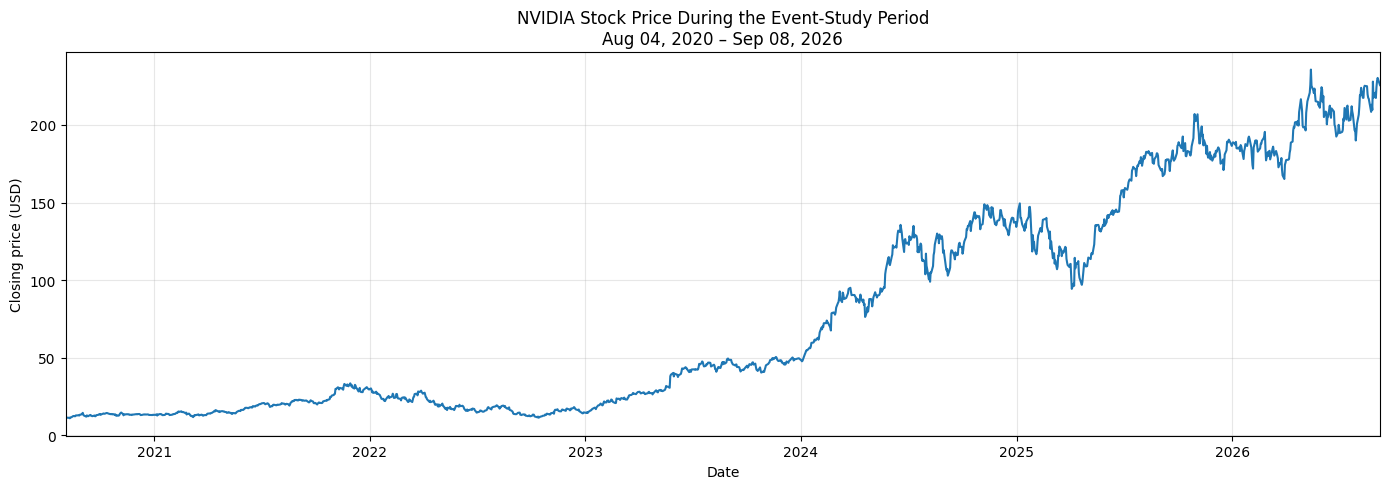

In [28]:
import matplotlib.pyplot as plt

# Use the overall calendar span covered by the event-study windows.
start_date = event_days["date"].min()
end_date = event_days["date"].max()

nvda_prices = (
    df_analysis.loc[
        df_analysis["date"].between(start_date, end_date)
        & df_analysis["is_trading_day"].eq(1),
        ["date", "nvda_close"]
    ]
    .dropna(subset=["nvda_close"])
    .sort_values("date")
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(nvda_prices["date"], nvda_prices["nvda_close"], linewidth=1.5)

ax.set_title(
    f"NVIDIA Stock Price During the Event-Study Period\n"
    f"{start_date:%b %d, %Y} – {end_date:%b %d, %Y}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (USD)")
ax.set_xlim(start_date, end_date)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

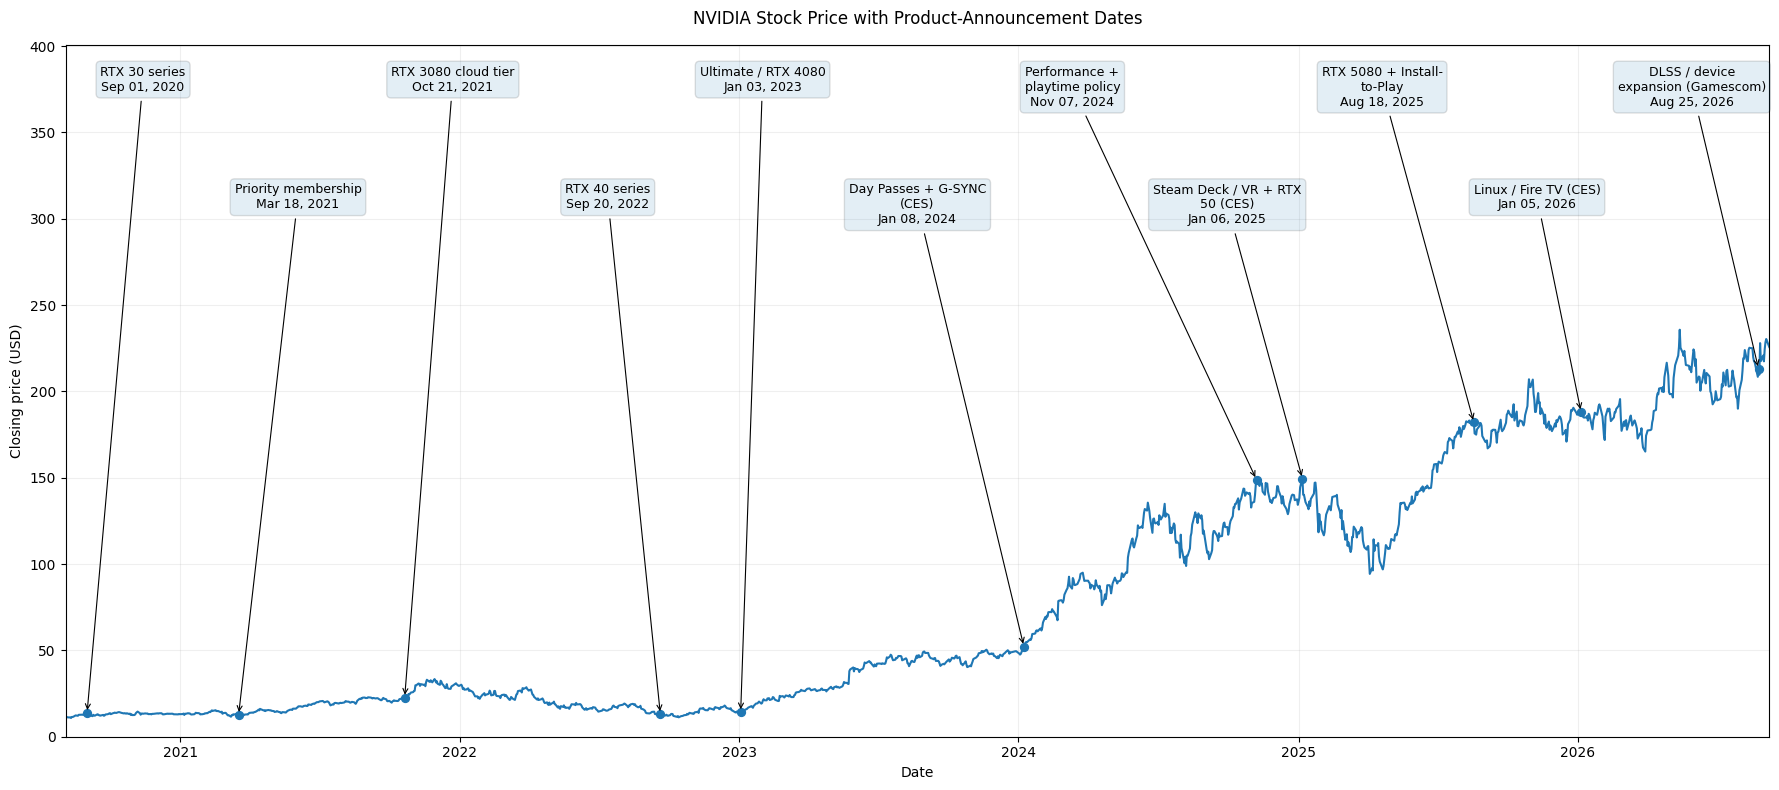

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import fill

# Reuse the exact price series from the previous cell.
prices = nvda_prices[["date", "nvda_close"]].copy()
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.dropna().sort_values("date")

if prices.empty:
    raise ValueError("No stock prices found. Run the preceding price-chart cell.")

# Use the existing sourced announcement catalogue.
announcements = events[["event_date", "event_name"]].copy()
announcements["event_date"] = pd.to_datetime(announcements["event_date"])

announcements = announcements.loc[
    announcements["event_date"].between(
        prices["date"].min(),
        prices["date"].max()
    )
].sort_values("event_date")

# Match each announcement to that day's close.
# For a non-trading date, use the next available trading day's close.
marked_events = pd.merge_asof(
    announcements,
    prices.rename(columns={"date": "price_date"}),
    left_on="event_date",
    right_on="price_date",
    direction="forward",
    tolerance=pd.Timedelta(days=7)
)

if marked_events.empty:
    raise ValueError("No announcements fall within the plotted date range.")

if marked_events["nvda_close"].isna().any():
    raise ValueError("Some announcements have no nearby price. Check the dates.")

# Redraw the price chart and mark the announcement locations.
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(
    prices["date"],
    prices["nvda_close"],
    linewidth=1.5
)

ax.scatter(
    marked_events["price_date"],
    marked_events["nvda_close"],
    s=32,
    zorder=3
)

# Reserve space above the price line for two rows of labels.
ax.set_ylim(0, prices["nvda_close"].max() * 1.7)
ax.set_xlim(prices["date"].min(), prices["date"].max())

for i, event in enumerate(marked_events.itertuples(index=False)):
    # Spread labels horizontally and alternate their height.
    label_x = (i + 0.5) / len(marked_events)
    label_y = 0.97 if i % 2 == 0 else 0.80

    label = (
        f"{fill(event.event_name, width=21)}\n"
        f"{event.event_date:%b %d, %Y}"
    )

    ax.annotate(
        label,
        xy=(event.price_date, event.nvda_close),
        xycoords="data",
        xytext=(label_x, label_y),
        textcoords="axes fraction",
        ha="center",
        va="top",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", linewidth=0.8),
        bbox=dict(boxstyle="round,pad=0.35", alpha=0.12)
    )

ax.set_title(
    "NVIDIA Stock Price with Product-Announcement Dates",
    pad=15
)
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (USD)")
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

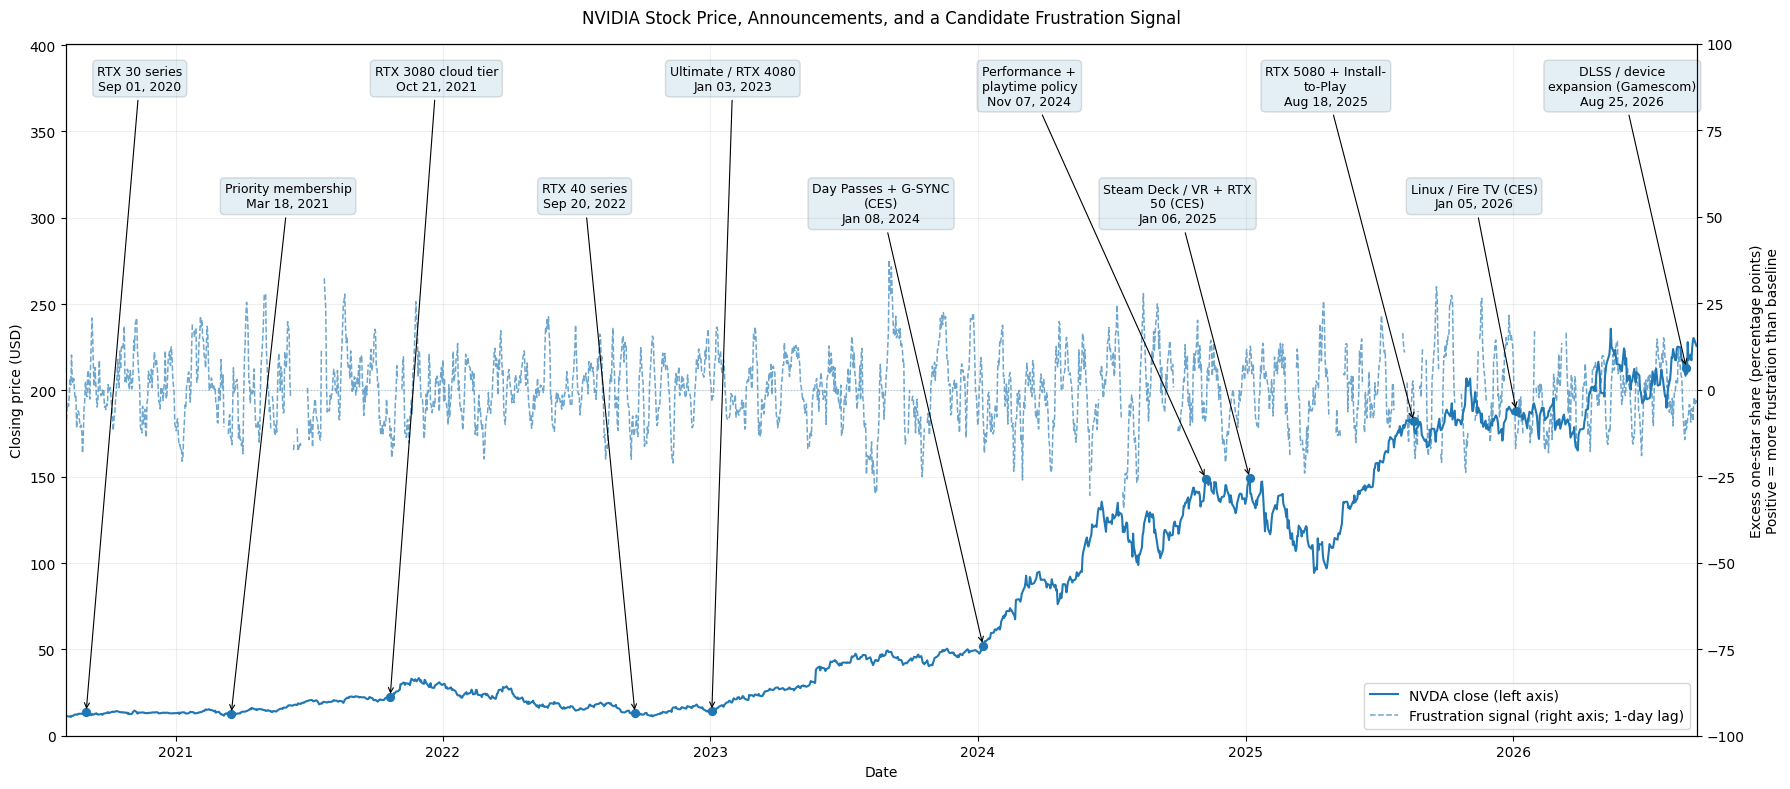

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Build the signal using the FULL calendar timeline, including zero-review days.
signal_data = df_analysis[
    ["date", "gfn_reviews_count", "gfn_one_star_share"]
].copy()

signal_data["date"] = pd.to_datetime(signal_data["date"]).dt.normalize()
signal_data = signal_data.set_index("date").sort_index().asfreq("D")

n = signal_data["gfn_reviews_count"]

# Recover daily one-star counts.
# Zero reviews means zero one-star reviews; other missing values stay missing.
one_star_n = (
    n * signal_data["gfn_one_star_share"]
).where(n.ne(0), 0)

# Recent seven days versus the NON-OVERLAPPING preceding thirty days.
recent_n = n.rolling(7, min_periods=7).sum()
baseline_n = n.shift(7).rolling(30, min_periods=30).sum()

recent_share = (
    one_star_n.rolling(7, min_periods=7).sum()
    / recent_n.where(recent_n.gt(0))
)

baseline_share = (
    one_star_n.shift(7).rolling(30, min_periods=30).sum()
    / baseline_n.where(baseline_n.gt(0))
)

# Illustrative sample-size screens, NOT statistical-significance thresholds.
MIN_RECENT_REVIEWS = 20
MIN_BASELINE_REVIEWS = 50

supported = (
    recent_n.ge(MIN_RECENT_REVIEWS)
    & baseline_n.ge(MIN_BASELINE_REVIEWS)
)

# At date t:
#   Recent window:   t-7 through t-1
#   Baseline window: t-37 through t-8
# No same-day or future-dated reviews enter the displayed indicator.
frustration_signal = (
    (100 * (recent_share - baseline_share))
    .where(supported)
    .shift(1)
    .rename("frustration_signal_pp")
)

signal_to_plot = frustration_signal.loc[
    prices["date"].min():prices["date"].max()
]

if not signal_to_plot.notna().any():
    raise ValueError("No supported signal values in the plotted period.")

# Reuse fig and ax from the preceding annotated stock-price cell.
# Remove only this overlay when rerunning, so extra axes do not accumulate.
for existing_ax in list(fig.axes):
    if existing_ax.get_label() == "gfn_signal_overlay":
        existing_ax.remove()

ax_signal = ax.twinx()
ax_signal.set_label("gfn_signal_overlay")

signal_line, = ax_signal.plot(
    signal_to_plot.index,
    signal_to_plot,
    linestyle="--",
    linewidth=1.1,
    alpha=0.65
)

ax_signal.axhline(0, linestyle=":", linewidth=0.8, alpha=0.4)

# Use the signal's full possible range, rather than fitting it to the price.
ax_signal.set_ylim(-100, 100)
ax_signal.set_ylabel(
    "Excess one-star share (percentage points)\n"
    "Positive = more frustration than baseline"
)

# Keep the original stock-price line and event labels above the overlay.
ax_signal.set_zorder(1)
ax.set_zorder(2)
ax.patch.set_visible(False)

ax.legend(
    handles=[ax.lines[0], signal_line],
    labels=[
        "NVDA close (left axis)",
        "Frustration signal (right axis; 1-day lag)"
    ],
    loc="lower right"
)

ax.set_title(
    "NVIDIA Stock Price, Announcements, and a Candidate Frustration Signal",
    pad=15
)

fig.tight_layout()
display(fig)

# From customer complaints to an announcement signal

**Research question:** Do GeForce NOW app reviews show unusual customer-sentiment shifts around NVIDIA/GeForce NOW product announcements?

We combined individual reviews with a daily market timeline, engineered measures of frustration, and compared review behavior before and after a curated set of announcements.

The story has two parts: **specific customer concerns are visible in the reviews**, but **a broader announcement response needs stronger evidence than a compelling chart**. Stock-price prediction is an extension, not an established result of this study.

*Sources: the uploaded raw reviews, the combined daily dataset, and the source-linked event catalogue and results already produced in this notebook.*

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Append after the existing analysis and run its earlier cells first.
required = ["df_analysis", "raw_reviews", "summary", "events",
            "placebo_strength", "sensitivity", "WINDOW"]
missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(f"Run the earlier analysis cells first. Missing: {missing}")

if WINDOW != 14:
    raise ValueError("This presentation summarizes the notebook's 14-day study.")

# Separate copies keep the original analysis unchanged.
story_daily = df_analysis.copy()
story_daily["date"] = pd.to_datetime(story_daily["date"]).dt.normalize()
story_daily = story_daily.set_index("date").sort_index()

assert story_daily.index.is_unique
assert story_daily.index.equals(pd.date_range(
    story_daily.index.min(), story_daily.index.max()
)), "Investigate missing calendar dates before plotting."

story_raw = raw_reviews.copy()
story_raw["date"] = pd.to_datetime(story_raw["posted_at"]).dt.normalize()

story_primary = summary.loc[
    summary["eligible"] & summary["group"].eq("GFN")
].sort_values("event_date").copy()

story_placebos = np.asarray(placebo_strength, dtype=float).copy()
story_policy = story_primary.set_index("event_id").loc["performance"]
story_anchor = pd.Timestamp(story_policy["event_date"])

STORY_DIR = Path("../data/processed/event_study/presentation")
STORY_DIR.mkdir(parents=True, exist_ok=True)


def story_finish(figure, filename, note):
    """Display and save one slide-ready figure, retaining its method note."""
    figure.text(0.02, 0.012, note, fontsize=9, va="bottom")
    figure.tight_layout(rect=(0, 0.075, 1, 1))
    figure.savefig(STORY_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


story_scope = pd.DataFrame({
    "Study component": [
        "Individual reviews",
        "Calendar days in review era",
        "Catalogued announcements",
        "Primary GFN events",
        "Before / after windows"
    ],
    "Scope": [
        f"{len(story_raw):,}",
        f"{len(story_daily):,}",
        str(len(events)),
        str(len(story_primary)),
        "14 days per side; announcement day excluded"
    ]
})

display(story_scope.set_index("Study component"))

display(Markdown(
    f"**Review period:** {story_daily.index.min():%b %d, %Y} to "
    f"{story_daily.index.max():%b %d, %Y}. "
    "These are collected app reviews, not a representative survey of all customers."
))

,Scope
Study component,
Individual reviews,"12,008"
Calendar days in review era,"2,310"
Catalogued announcements,11
Primary GFN events,9
Before / after windows,14 days per side; announcement day excluded


**Review period:** May 24, 2020 to Sep 19, 2026. These are collected app reviews, not a representative survey of all customers.

## 1. The most dramatic days were often the least supported

Before interpreting a sharp sentiment drop, we checked **how many reviews produced that daily average**.

A score from one reviewer is an observation about that reviewer—not evidence of a broad customer reaction. This is why review count became a core feature, why we weighted multi-day averages by review count, and why we retained no-review days without inventing neutral sentiment.

**Read the chart:** crosses mark the 20 most negative daily averages. Their concentration at low review counts is a warning against telling the story from extreme scores alone.

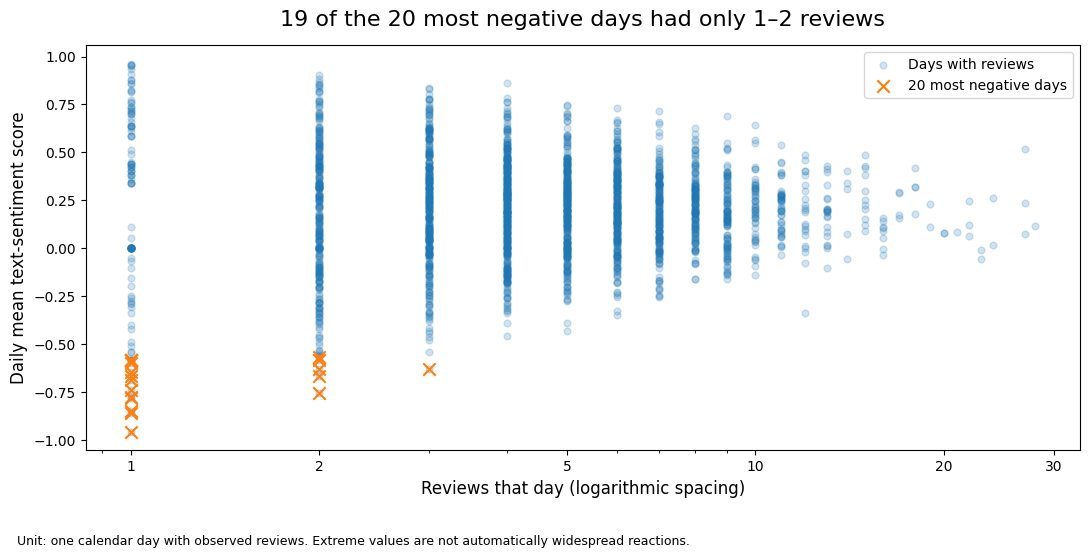

In [32]:
story_review_days = story_daily.loc[
    story_daily["gfn_reviews_count"].gt(0)
].dropna(subset=["gfn_sentiment_score"])

story_extreme = (
    story_review_days
    .sort_values("gfn_sentiment_score")
    .head(20)
)

story_small_n = int(story_extreme["gfn_reviews_count"].le(2).sum())

story_fig, story_ax = plt.subplots(figsize=(11, 5.6))

story_ax.scatter(
    story_review_days["gfn_reviews_count"],
    story_review_days["gfn_sentiment_score"],
    s=24,
    alpha=0.2,
    label="Days with reviews"
)

story_ax.scatter(
    story_extreme["gfn_reviews_count"],
    story_extreme["gfn_sentiment_score"],
    s=80,
    marker="x",
    linewidths=1.5,
    label="20 most negative days"
)

story_ax.set_xscale("log")
story_ax.set_xticks(
    [1, 2, 5, 10, 20, 30],
    labels=[1, 2, 5, 10, 20, 30]
)

story_ax.set_xlabel(
    "Reviews that day (logarithmic spacing)",
    fontsize=12
)
story_ax.set_ylabel("Daily mean text-sentiment score", fontsize=12)

story_ax.set_title(
    f"{story_small_n} of the 20 most negative days had only 1–2 reviews",
    fontsize=16,
    pad=14
)

story_ax.legend(loc="upper right")

story_finish(
    story_fig,
    "01_small_samples.png",
    "Unit: one calendar day with observed reviews. "
    "Extreme values are not automatically widespread reactions."
)

## 2. Feature engineering: distinguish frustration from noise

| Feature | What it adds to the story |
|---|---|
| `gfn_reviews_count`, `gfn_one_star_share` | Separate the amount of review activity from the proportion of one-star reviews. |
| `sentiment_7d`, `sentiment_30d`, `rating_7d`, `rating_30d` | Review-weighted calendar-window trends instead of equally weighting sparse and busy days. |
| `sentiment_shift`, `rating_shift`, `review_volume_anomaly` | Exploratory short-/long-term comparisons and a rolling review-count z-score. These are not the fixed-baseline event effects. |
| `delta_sentiment`, `delta_rating`, `delta_one_star_share` | Compare fixed post-announcement and pre-announcement windows, excluding day zero. |
| `frustration_signal` | Compare recent one-star share with an earlier, non-overlapping baseline, using only earlier recorded review dates. |

### A candidate frustration indicator

**At date t: 100 × [one-star share over t−7…t−1 minus one-star share over t−37…t−8].**

A value of **+10** means the recent one-star share is 10 percentage points above baseline. We require at least 20 recent and 50 baseline reviews; these are screening heuristics, not confidence thresholds.

We illustrate it around the Performance/playtime-policy announcement because the review text contains policy-specific concerns—not because this date maximized the indicator.

The earlier 7-minus-30-day EDA shifts use overlapping windows, and the earlier volume z-score includes the current day; neither is substituted for this lagged indicator or the event-study baseline.

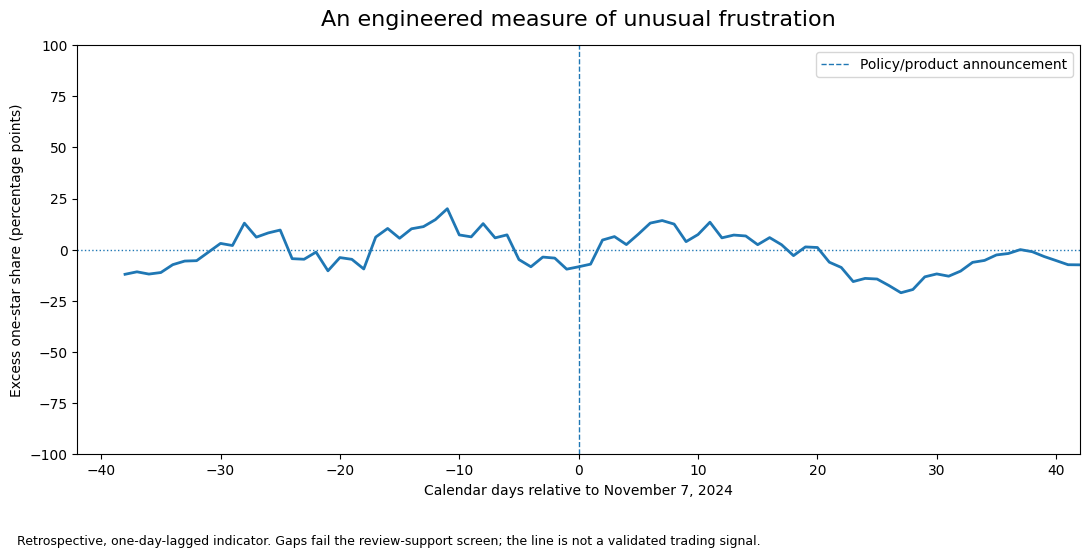

In [33]:
# Rebuild the same lagged indicator used in the stock-price overlay.
story_n = story_daily["gfn_reviews_count"]

story_one_n = (
    story_n * story_daily["gfn_one_star_share"]
).where(story_n.ne(0), 0)

# At date t:
# Recent window:   t-7 through t-1
# Baseline window: t-37 through t-8
story_recent_n = story_n.shift(1).rolling(7, min_periods=7).sum()
story_baseline_n = story_n.shift(8).rolling(30, min_periods=30).sum()

story_recent_share = (
    story_one_n.shift(1).rolling(7, min_periods=7).sum()
    / story_recent_n.where(story_recent_n.gt(0))
)

story_baseline_share = (
    story_one_n.shift(8).rolling(30, min_periods=30).sum()
    / story_baseline_n.where(story_baseline_n.gt(0))
)

story_signal = (
    100 * (story_recent_share - story_baseline_share)
).where(
    story_recent_n.ge(20) & story_baseline_n.ge(50)
)

story_local = story_signal.loc[
    story_anchor - pd.Timedelta(days=42):
    story_anchor + pd.Timedelta(days=42)
]

story_fig, story_ax = plt.subplots(figsize=(11, 5.6))

story_ax.plot(
    (story_local.index - story_anchor).days,
    story_local,
    linewidth=2
)

story_ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    label="Policy/product announcement"
)
story_ax.axhline(0, linestyle=":", linewidth=1)

story_ax.set(
    xlim=(-42, 42),
    ylim=(-100, 100),
    xlabel="Calendar days relative to November 7, 2024",
    ylabel="Excess one-star share (percentage points)"
)

story_ax.set_title(
    "An engineered measure of unusual frustration",
    fontsize=16,
    pad=14
)
story_ax.legend()

story_finish(
    story_fig,
    "02_frustration_feature.png",
    "Retrospective, one-day-lagged indicator. Gaps fail the review-support screen; "
    "the line is not a validated trading signal."
)

## 3. Surprise: a “Positive” label did not always mean a satisfied customer

We compared the dataset's supplied text-sentiment labels with the star ratings and then inspected actual review text.

The disagreement matters because the interpretation of an announcement can change with the chosen sentiment measure.

**A star-rating disagreement is not itself a classifier error rate:** some reviews mix praise and criticism. However, plainly critical examples justify auditing the scoring method before treating the label as ground truth.

**Read the chart:** within each star-rating group, what percentage of reviews received a supplied “Positive” text label?

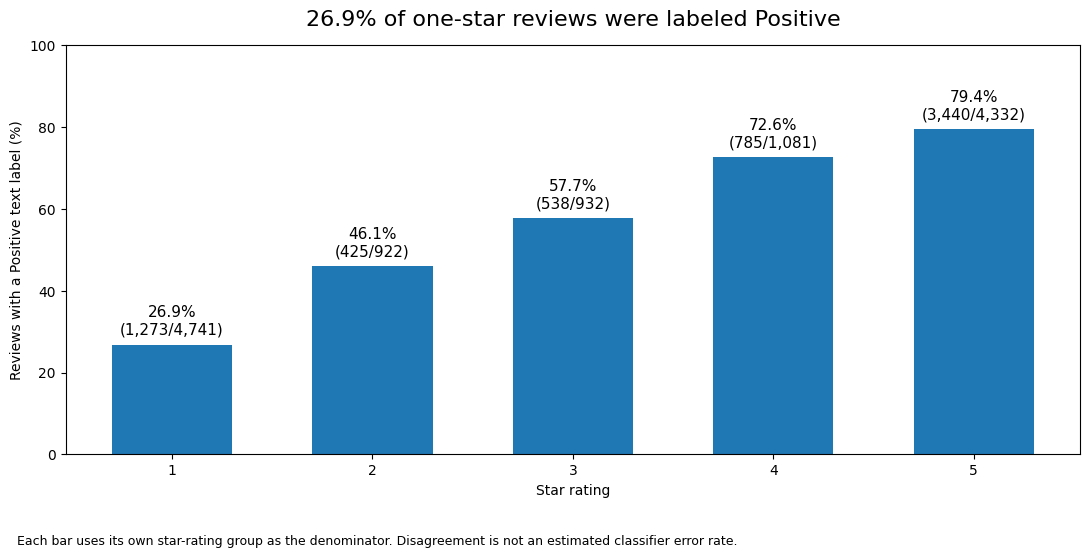

> “Doesn't work, it rejected my account”

**Rating:** 1/5 · **Supplied score:** +0.4023 · **Supplied label:** Positive

*Illustrative example selected for inspection—not a random error audit.*

In [34]:
story_label_audit = (
    story_raw.assign(
        is_positive=story_raw["sentiment_category"].eq("Positive")
    )
    .groupby("rating")
    .agg(
        reviews=("review_id", "size"),
        positive=("is_positive", "sum")
    )
    .reindex([1, 2, 3, 4, 5])
)

story_label_audit["positive_pct"] = (
    100 * story_label_audit["positive"]
    / story_label_audit["reviews"]
)

story_one_star_audit = story_label_audit.loc[1]

story_fig, story_ax = plt.subplots(figsize=(11, 5.6))

story_bars = story_ax.bar(
    story_label_audit.index,
    story_label_audit["positive_pct"],
    width=0.6
)

story_ax.bar_label(
    story_bars,
    labels=[
        f"{row.positive_pct:.1f}%\n"
        f"({int(row.positive):,}/{int(row.reviews):,})"
        for row in story_label_audit.itertuples()
    ],
    padding=5,
    fontsize=11
)

story_ax.set(
    ylim=(0, 100),
    xticks=[1, 2, 3, 4, 5],
    xlabel="Star rating",
    ylabel="Reviews with a Positive text label (%)"
)

story_ax.set_title(
    f"{story_one_star_audit.positive_pct:.1f}% of one-star reviews were labeled Positive",
    fontsize=16,
    pad=14
)

story_finish(
    story_fig,
    "03_sentiment_label_audit.png",
    "Each bar uses its own star-rating group as the denominator. "
    "Disagreement is not an estimated classifier error rate."
)

# Revisit the previously audited example; omit author names.
story_example = story_raw.loc[
    story_raw["review_text"].str.contains(
        "rejected my account",
        case=False,
        regex=False,
        na=False
    )
]

if not story_example.empty:
    story_row = story_example.iloc[0]

    display(Markdown(
        f'> “{story_row["review_text"].strip()}”\n\n'
        f'**Rating:** {story_row["rating"]}/5 · '
        f'**Supplied score:** {story_row["sentiment_score"]:+.4f} · '
        f'**Supplied label:** {story_row["sentiment_category"]}\n\n'
        '*Illustrative example selected for inspection—not a random error audit.*'
    ))

## 4. A concrete case: customers named the playtime policy

For the **November 7, 2024 Performance/playtime-policy announcement**, the collected sample had a larger one-star share and a lower average rating in the following fourteen days than in the previous fourteen days.

The text provides something the numerical score alone cannot: **some reviewers explicitly identified the playtime limit as their concern**.

This is a descriptive case study of the collected reviews. The announcement bundled several changes; a before/after difference cannot isolate their effects, establish causation, or measure the views of all customers.

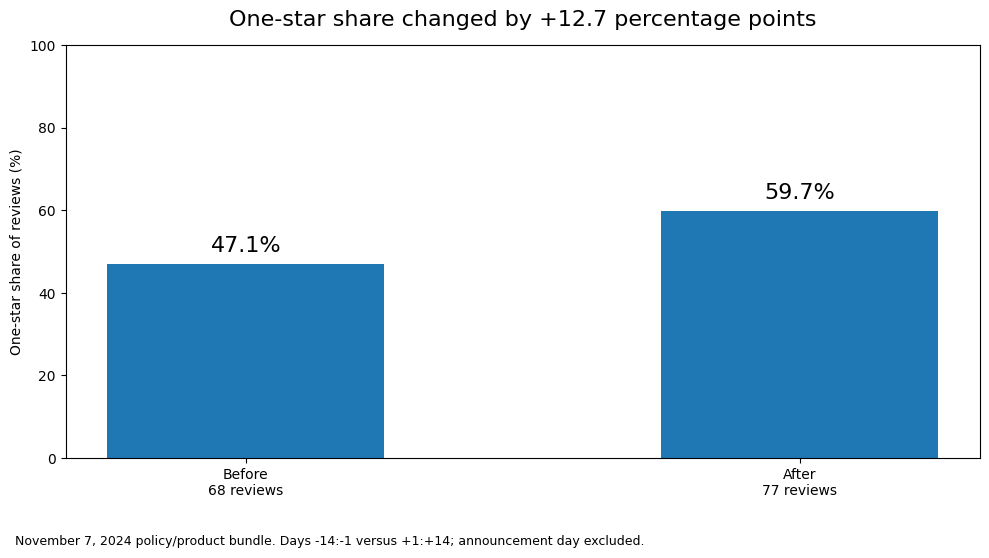

,Before,After,Change
Metric,,,
Review count,68,77,+9
Mean rating,2.82,2.43,-0.39 stars
Mean text sentiment,0.199,0.157,-0.042


> “Remove 100 hours limit”

Posted Nov 09, 2024; rating 1/5; text score 0.0. This selected excerpt identifies a concern; it is not a frequency estimate.

[Announcement source retained in the catalogue](https://blogs.nvidia.com/blog/geforce-now-thursday-performance-membership/)

In [35]:
story_before_after = [
    100 * story_policy["pre_one_star_share"],
    100 * story_policy["post_one_star_share"]
]

story_pp_change = 100 * story_policy["delta_one_star_share"]

story_fig, story_ax = plt.subplots(figsize=(10, 5.6))

story_bars = story_ax.bar(
    [
        f'Before\n{int(story_policy["pre_reviews"])} reviews',
        f'After\n{int(story_policy["post_reviews"])} reviews'
    ],
    story_before_after,
    width=0.5
)

story_ax.bar_label(
    story_bars,
    labels=[f"{x:.1f}%" for x in story_before_after],
    padding=6,
    fontsize=16
)

story_ax.set(
    ylim=(0, 100),
    ylabel="One-star share of reviews (%)"
)

story_ax.set_title(
    f"One-star share changed by {story_pp_change:+.1f} percentage points",
    fontsize=16,
    pad=14
)

story_finish(
    story_fig,
    "04_policy_case.png",
    "November 7, 2024 policy/product bundle. "
    "Days -14:-1 versus +1:+14; announcement day excluded."
)

story_case_table = pd.DataFrame({
    "Metric": ["Review count", "Mean rating", "Mean text sentiment"],
    "Before": [
        f'{story_policy["pre_reviews"]:.0f}',
        f'{story_policy["pre_rating"]:.2f}',
        f'{story_policy["pre_sentiment"]:.3f}'
    ],
    "After": [
        f'{story_policy["post_reviews"]:.0f}',
        f'{story_policy["post_rating"]:.2f}',
        f'{story_policy["post_sentiment"]:.3f}'
    ],
    "Change": [
        f'{story_policy["post_reviews"] - story_policy["pre_reviews"]:+.0f}',
        f'{story_policy["delta_rating"]:+.2f} stars',
        f'{story_policy["delta_sentiment"]:+.3f}'
    ]
})

display(story_case_table.set_index("Metric"))

story_post_days = (story_raw["date"] - story_anchor).dt.days

story_quote = story_raw.loc[
    story_post_days.between(1, 14)
    & story_raw["review_text"].str.contains(
        "Remove 100 hours limit",
        case=False,
        regex=False,
        na=False
    )
]

if not story_quote.empty:
    story_row = story_quote.iloc[0]

    display(Markdown(
        f'> “{story_row["review_text"].strip()}”\n\n'
        f'Posted {story_row["date"]:%b %d, %Y}; '
        f'rating {story_row["rating"]}/5; '
        f'text score {story_row["sentiment_score"]:.1f}. '
        'This selected excerpt identifies a concern; it is not a frequency estimate.'
    ))

display(Markdown(
    f'[Announcement source retained in the catalogue]({story_policy["source_url"]})'
))

## 5. Did that case generalize across announcements?

We compared two different measurements for every eligible GFN event: the change in average text sentiment and the change in average star rating.

**Read the chart:** right means text sentiment increased; up means ratings increased. Points in the lower-right or upper-left show opposite directions. Zero is a reference line, not a significance threshold.

Each point represents an announcement's review-weighted before/after comparison. The overall summaries give each event equal weight. This avoids letting one high-volume event determine the aggregate story.

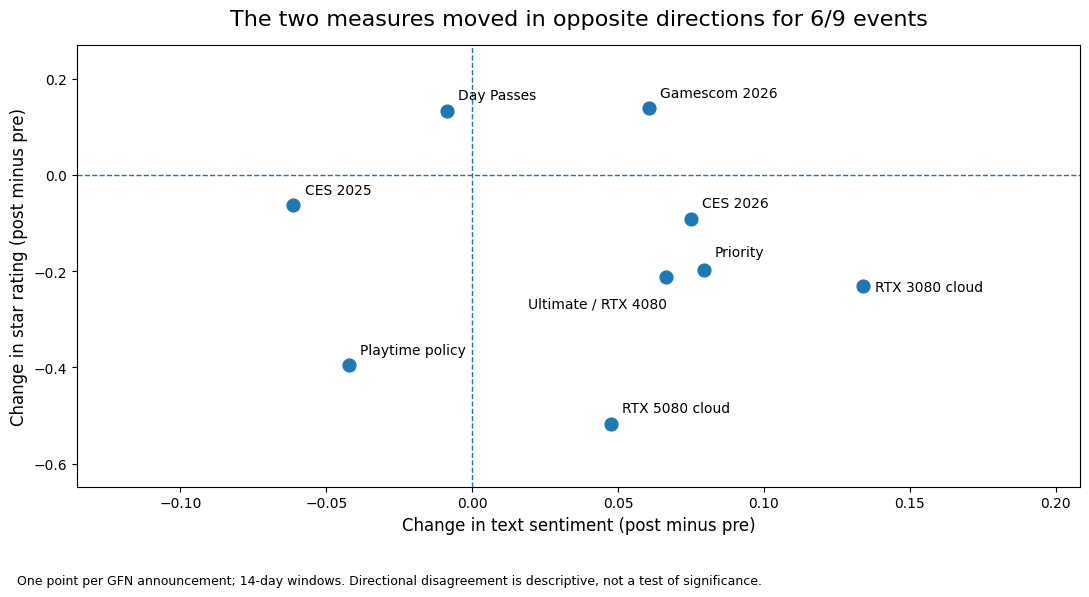

**Equal-event mean changes:** text sentiment +0.039; rating -0.159 stars. Text sentiment increased for 6 events; ratings decreased for 7.

In [36]:
story_disagree = (
    story_primary["delta_sentiment"]
    * story_primary["delta_rating"] < 0
).sum()

story_short_names = {
    "priority": "Priority",
    "gfn3080": "RTX 3080 cloud",
    "ultimate": "Ultimate / RTX 4080",
    "daypasses": "Day Passes",
    "performance": "Playtime policy",
    "ces2025": "CES 2025",
    "gfn5080": "RTX 5080 cloud",
    "ces2026": "CES 2026",
    "gamescom2026": "Gamescom 2026"
}

story_offsets = {
    "ultimate": (-100, -22),
    "priority": (8, 10),
    "gfn3080": (8, -4)
}

story_fig, story_ax = plt.subplots(figsize=(11, 6))

story_ax.scatter(
    story_primary["delta_sentiment"],
    story_primary["delta_rating"],
    s=85
)

story_ax.axvline(0, linestyle="--", linewidth=1)
story_ax.axhline(0, linestyle="--", linewidth=1)

for row in story_primary.itertuples():
    story_ax.annotate(
        story_short_names.get(row.event_id, row.event_name),
        (row.delta_sentiment, row.delta_rating),
        xytext=story_offsets.get(row.event_id, (8, 8)),
        textcoords="offset points",
        fontsize=10
    )

story_ax.margins(x=0.38, y=0.20)

story_ax.set_xlabel(
    "Change in text sentiment (post minus pre)",
    fontsize=12
)
story_ax.set_ylabel(
    "Change in star rating (post minus pre)",
    fontsize=12
)

story_ax.set_title(
    f"The two measures moved in opposite directions for "
    f"{story_disagree}/{len(story_primary)} events",
    fontsize=16,
    pad=14
)

story_finish(
    story_fig,
    "05_measure_disagreement.png",
    "One point per GFN announcement; 14-day windows. "
    "Directional disagreement is descriptive, not a test of significance."
)

display(Markdown(
    f'**Equal-event mean changes:** text sentiment '
    f'{story_primary["delta_sentiment"].mean():+.3f}; '
    f'rating {story_primary["delta_rating"].mean():+.3f} stars. '
    f'Text sentiment increased for '
    f'{story_primary["delta_sentiment"].gt(0).sum()} events; '
    f'ratings decreased for '
    f'{story_primary["delta_rating"].lt(0).sum()}.'
))

## 6. The key test: were the changes unusually large?

An announcement-period change is not enough by itself. We compared the observed **average absolute text-sentiment change** with the same statistic from the notebook's matched-date comparison schedules.

Absolute changes retain shifts in either direction instead of allowing positive and negative changes to cancel.

The comparison dates were nearby, matched on weekday, subject to the same coverage requirements, and excluded windows around catalogued announcements. Each simulated schedule used non-overlapping comparison windows.

**Read the chart:** an unusually large announcement response would sit far to the right of the comparison distribution. In this study, the observed value sits inside its ordinary range.

This is a descriptive comparison—not a randomized-experiment p-value. The comparison dates may still include other news, outages, or service changes.

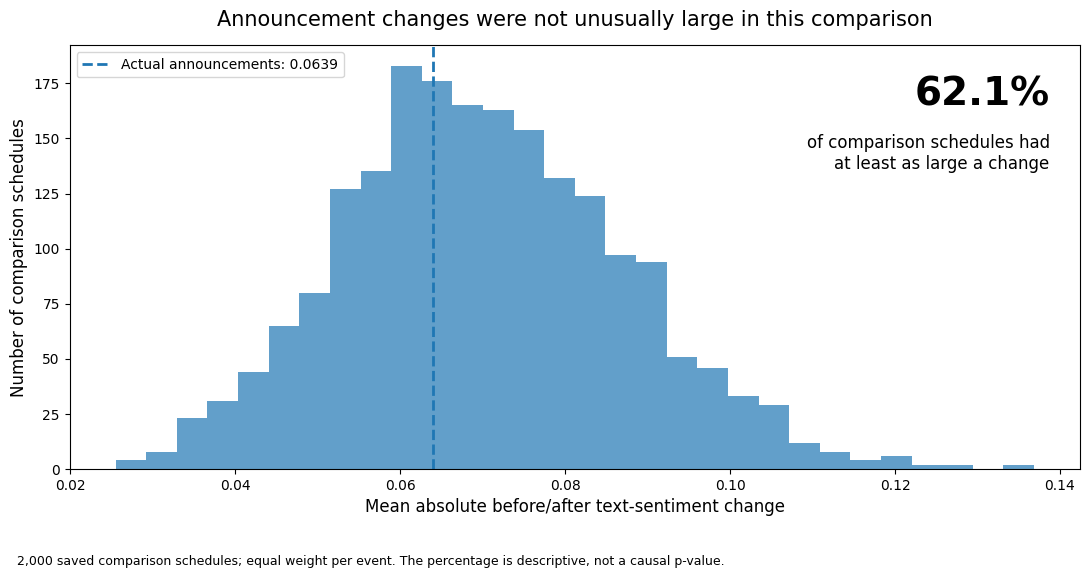

**Actual mean absolute change: 0.0639.** Median comparison change: 0.0691. This does not establish that announcements never matter; it limits the aggregate claim supported here.

In [37]:
# Reuse the exact schedules from the study.
# Do not resample until a result looks stronger.
story_observed = story_primary["delta_sentiment"].abs().mean()
story_exceedance = np.mean(story_placebos >= story_observed)

story_fig, story_ax = plt.subplots(figsize=(11, 5.8))

story_ax.hist(story_placebos, bins=30, alpha=0.7)

story_ax.axvline(
    story_observed,
    linestyle="--",
    linewidth=2,
    label=f"Actual announcements: {story_observed:.4f}"
)

story_ax.text(
    0.97, 0.93,
    f"{story_exceedance:.1%}",
    transform=story_ax.transAxes,
    ha="right",
    va="top",
    fontsize=28,
    fontweight="bold"
)

story_ax.text(
    0.97, 0.79,
    "of comparison schedules had\nat least as large a change",
    transform=story_ax.transAxes,
    ha="right",
    va="top",
    fontsize=12
)

story_ax.set_xlabel(
    "Mean absolute before/after text-sentiment change",
    fontsize=12
)
story_ax.set_ylabel("Number of comparison schedules", fontsize=12)

story_ax.set_title(
    "Announcement changes were not unusually large in this comparison",
    fontsize=15,
    pad=14
)

story_ax.legend(loc="upper left")

story_finish(
    story_fig,
    "06_matched_date_comparison.png",
    f"{len(story_placebos):,} saved comparison schedules; equal weight per event. "
    "The percentage is descriptive, not a causal p-value."
)

display(Markdown(
    f"**Actual mean absolute change: {story_observed:.4f}.** "
    f"Median comparison change: {np.median(story_placebos):.4f}. "
    "This does not establish that announcements never matter; "
    "it limits the aggregate claim supported here."
))

## 7. The conclusion also depended on the time window

We repeated the before/after comparison with 7-, 14-, and 28-day windows. This chart uses the **same seven-event sensitivity cohort** at every window length, holding the event dates unchanged.

The average rating difference changes sign between the 14-day and 28-day settings. Therefore, “announcements generally reduce customer satisfaction” is not a stable conclusion from this analysis.

The seven-event robustness sample differs from the nine-event primary sample. We do not compare a nine-event mean at one window with a seven-event mean at another and call that window sensitivity.

Longer windows also admit more unrelated developments; they are not automatically more informative.

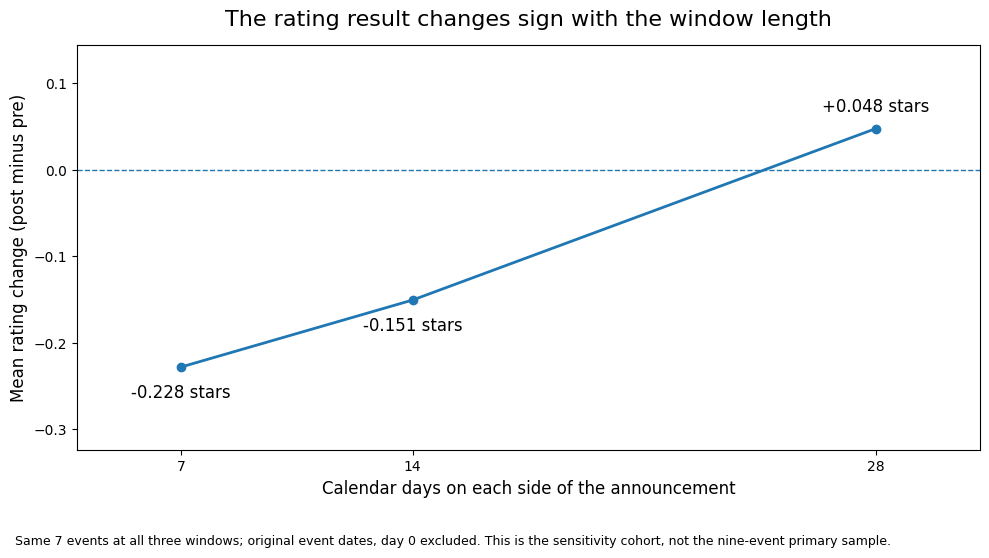

In [38]:
story_robustness = sensitivity.loc[
    sensitivity["anchor_shift_days"].eq(0)
].sort_values("window_days_each_side").copy()

assert story_robustness["events_in_fixed_cohort"].nunique() == 1

story_cohort_n = int(
    story_robustness["events_in_fixed_cohort"].iloc[0]
)

story_fig, story_ax = plt.subplots(figsize=(10, 5.6))

story_ax.plot(
    story_robustness["window_days_each_side"],
    story_robustness["mean_rating_change"],
    marker="o",
    linewidth=2
)

story_ax.axhline(0, linestyle="--", linewidth=1)

for row in story_robustness.itertuples():
    story_ax.annotate(
        f"{row.mean_rating_change:+.3f} stars",
        (row.window_days_each_side, row.mean_rating_change),
        xytext=(0, 12 if row.mean_rating_change > 0 else -22),
        textcoords="offset points",
        ha="center",
        fontsize=12
    )

story_ax.set_xticks([7, 14, 28])

story_ax.set_xlabel(
    "Calendar days on each side of the announcement",
    fontsize=12
)
story_ax.set_ylabel(
    "Mean rating change (post minus pre)",
    fontsize=12
)

story_ax.margins(x=0.15, y=0.35)

story_ax.set_title(
    "The rating result changes sign with the window length",
    fontsize=16,
    pad=14
)

story_finish(
    story_fig,
    "07_window_sensitivity.png",
    f"Same {story_cohort_n} events at all three windows; original event dates, "
    "day 0 excluded. This is the sensitivity cohort, not the nine-event primary sample."
)

## 8. What did we actually learn?

**Customer feedback: useful.** The review text identified concrete policy-related complaints. The policy case also showed a lower average rating and a higher one-star share in the post period, without establishing causation or representing all customers.

**Measurement: consequential.** Sparse daily samples and disagreements between star ratings and supplied text labels could change the story. Review counts, weighted calendar averages, fixed event baselines, and a lagged frustration indicator made those limitations visible rather than removing them.

**A general announcement signal: not established.** Text-sentiment changes were not unusually large relative to the matched comparison schedules, and the rating conclusion depended on the analysis window.

**A stock-price signal: still unvalidated.** Overlaying the candidate indicator on NVIDIA's price motivates a hypothesis; this notebook has not demonstrated incremental prediction of future returns. A lag based on recorded timestamps also does not establish that the collected data or scores were historically available at that moment.

### Takeaway

> **App reviews were useful for understanding specific customer concerns. This pilot did not establish a general announcement detector or a trading signal.**

*Scope limits: curated event list, uncertain review-sampling completeness, undocumented time zones and announcement exposure, concurrent service changes, heterogeneous events, and no independent measure of population-wide customer sentiment.*